In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy
import multiprocessing as mp
import multiprocessing
from scipy.sparse import csr_matrix
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import scipy.interpolate as interp 
import scipy.integrate as integrate

In [2]:
### 0401 redo
## Try f0g1 simulation
Nqu=5;
Nres=3;
## define qubit 
omegaq=2*np.pi*7986;
aharmon=-2*np.pi*372;

qubitobj=basis(Nqu,2);
bqub=destroy(Nqu);
bqubd=create(Nqu);

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[2,3]=1
fhdecayop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[2,2]=-1
zeromatrixxtmp[3,3]=1
fhdechoop=Qobj(zeromatrixxtmp)

## define resonator
omegares=2*np.pi*9380;
# cfcoupling=2*np.pi*100;
# cfcoupling=2*np.pi*10;#freq=-94
# cfcoupling=2*np.pi*50;

cavobj=basis(Nres);
acav=destroy(Nres);
acavd=create(Nres);
## define filter
# omegafilter=2*np.pi*10000;
# kappa=2*np.pi*400
# kappa=2*np.pi*40*10
kappa=2*np.pi*20
# filterobj=basis(Nfilter);
# fcav=destroy(Nfilter);
# fcavd=create(Nfilter);

##### 
c_ops=[];
c_ops.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav))
## qubit-resonator coupling strength
gqcav=2*np.pi*150;

## Qubit have an intrisc infinite lifetime
inflifetime=1;
if inflifetime:
    print("Qubit lifetime infinity, despite Purcell")
    gammaT1ge=0;
    gammaTphige=0;
    gammaT1ef=0;
    gammaTphief=0;
    gammaT1fh=0;
    gammaTphifh=0;
    # T1geapprox=1/(kappa*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter)**2-cfcoupling**2)**2)*(1+gqcav**2/2/((omegaq-omegafilter)-cfcoupling)**2+gqcav**2/2/((omegaq-omegafilter)+cfcoupling)**2)
    # T1efapprox=1/(kappa*2*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+aharmon)**2-cfcoupling**2)**2)*(1+gqcav**2/((omegaq-omegafilter+aharmon)-cfcoupling)**2+gqcav**2/((omegaq-omegafilter+aharmon)+cfcoupling)**2)
    # T1fhapprox=1/(kappa*3*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+2*aharmon)**2-cfcoupling**2)**2)*(1+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)-cfcoupling)**2+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)+cfcoupling)**2)
    # T2geapprox=2*T1geapprox
    # T2efapprox=2*T1efapprox
    # T2fhapprox=2*T1fhapprox
    # keffres=4*cfcoupling**2/kappa/2/np.pi
    chieff=np.abs(1/2/np.pi*2*gqcav**2*aharmon/(omegaq-omegares)/(omegaq-omegares+aharmon))
    # print("T1ge(us)="+str(T1geapprox))
    # print("T1ef(us)="+str(T1efapprox))
    # print("T1fh(us)="+str(T1fhapprox))
    # print("T2ge(us)="+str(T2geapprox))
    # print("T2ef(us)="+str(T2efapprox))
    # print("T2fh(us)="+str(T2fhapprox))
    # print("kappa_eff_res/2pi(MHz)="+str(keffres))
    print("chi_eff/2pi(MHz)="+str(chieff))
    c_ops=[];
    c_ops.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav))
else:
    print("Qubit lifetime has been defined")
    T1geapprox=15
    T1efapprox=12
    T1fhapprox=3
    T2geapprox=15
    T2efapprox=5
    T2fhapprox=0.5
    gammaT1ge=1/T1geapprox-(kappa*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter)**2-cfcoupling**2)**2)*(1+gqcav**2/2/((omegaq-omegafilter)-cfcoupling)**2+gqcav**2/2/((omegaq-omegafilter)+cfcoupling)**2);
    gammaTphige=(1/T2geapprox-1/T1geapprox/2)/2;
    gammaT1ef=1/T1efapprox-(kappa*2*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+aharmon)**2-cfcoupling**2)**2)*(1+gqcav**2/((omegaq-omegafilter+aharmon)-cfcoupling)**2+gqcav**2/((omegaq-omegafilter+aharmon)+cfcoupling)**2);
    gammaTphief=(1/T2efapprox-1/T1efapprox/2)/2;
    gammaT1fh=1/T1fhapprox-(kappa*3*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+2*aharmon)**2-cfcoupling**2)**2)*(1+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)-cfcoupling)**2+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)+cfcoupling)**2);
    gammaTphifh=(1/T2fhapprox-1/T1fhapprox/2)/2;
    keffres=4*cfcoupling**2/kappa/2/np.pi
    chieff=np.abs(1/2/np.pi*2*gqcav**2*aharmon/(omegaq-omegafilter)/(omegaq-omegafilter+aharmon))
    print("T1ge(us)="+str(T1geapprox))
    print("T1ef(us)="+str(T1efapprox))
    print("T1fh(us)="+str(T1fhapprox))
    print("T2ge(us)="+str(T2geapprox))
    print("T2ef(us)="+str(T2efapprox))
    print("T2fh(us)="+str(T2fhapprox))
    print("kappa_eff_res/2pi(MHz)="+str(keffres))
    print("chi_eff/2pi(MHz)="+str(chieff))
    c_ops=[];
    c_ops.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav))
    c_ops.append(np.sqrt(gammaT1ge)*tensor(gedecayop,qeye(Nres)))
    c_ops.append(np.sqrt(gammaT1ef)*tensor(efdecayop,qeye(Nres)))
    c_ops.append(np.sqrt(gammaT1fh)*tensor(fhdecayop,qeye(Nres)))
    c_ops.append(np.sqrt(gammaTphige)*tensor(gedechoop,qeye(Nres)))
    c_ops.append(np.sqrt(gammaTphief)*tensor(efdechoop,qeye(Nres)))
    c_ops.append(np.sqrt(gammaTphifh)*tensor(fhdechoop,qeye(Nres)))

Qubit lifetime infinity, despite Purcell
chi_eff/2pi(MHz)=6.799891461708571


In [3]:
omega_rotate=2*np.pi*9000 #in the rotating frame->reduce the oscilation in the mode function!

In [4]:
## find states
H0=(omegaq-omega_rotate)*tensor(bqubd*bqub,qeye(Nres))+aharmon/2*tensor(bqubd*bqubd*bqub*bqub,qeye(Nres))\
+(omegares-omega_rotate)*tensor(qeye(Nqu),acavd*acav)+gqcav*(tensor(bqub,acavd)+tensor(bqubd,acav))
                                                    
eigsystem=H0.eigenstates()

i0=tensor(basis(Nqu,4),cavobj);
h0=tensor(basis(Nqu,3),cavobj);
f0=tensor(basis(Nqu,2),cavobj);
e0=tensor(basis(Nqu,1),cavobj);
g0=tensor(basis(Nqu),cavobj);

g1=tensor(basis(Nqu),basis(Nres,1));
e1=tensor(basis(Nqu,1),basis(Nres,1));

overlaplisti0=[fidelity(i0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlaplisth0=[fidelity(h0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlaplistf0=[fidelity(f0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlapliste0=[fidelity(e0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlaplistg0=[fidelity(g0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]

overlaplistg1=[fidelity(g1,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlapliste1=[fidelity(e1,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]

maxindexi0=overlaplisti0.index(max(overlaplisti0))
maxindexh0=overlaplisth0.index(max(overlaplisth0))
maxindexf0=overlaplistf0.index(max(overlaplistf0))
maxindexe0=overlapliste0.index(max(overlapliste0))
maxindexg0=overlaplistg0.index(max(overlaplistg0))

maxindexg1=overlaplistg1.index(max(overlaplistg1))

maxindexe1=overlapliste1.index(max(overlapliste1))

omegaf0g1=np.abs(eigsystem[0][maxindexf0]-eigsystem[0][maxindexg1])
omegah0e1=np.abs(eigsystem[0][maxindexh0]-eigsystem[0][maxindexe1])


In [5]:
## Energy of f0g1 photon
energy_cav_gstate=eigsystem[0][maxindexg1]-eigsystem[0][maxindexg0]
print("Cavity Freq at g state="+str(energy_cav_gstate/2/np.pi/1000)+" GHz")

Cavity Freq at g state=0.3959579230221088 GHz


In [6]:
initialstatef0=eigsystem[1][maxindexf0]
initialstateh0=eigsystem[1][maxindexh0]
initialstatee0=eigsystem[1][maxindexe0]
initialstateg0=g0

In [7]:
def strack_shift_he(drivepower,omegadrive):
    drivedetun=aharmon*(2*(omegaq-omegadrive)**2-3*aharmon**2+aharmon*(omegaq-omegadrive))\
    /(2*(omegaq-omegadrive)*((omegaq-omegadrive)+aharmon)*(2*aharmon+(omegaq-omegadrive))*(3*aharmon+(omegaq-omegadrive)))\
    *drivepower**2
    return drivedetun

def strack_shift_fg(drivepower,omegadrive):
    drivedetun=aharmon*((omegaq-omegadrive)*2+aharmon)/(2*(omegaq-omegadrive)*((omegaq-omegadrive)+aharmon)*(2*aharmon+(omegaq-omegadrive)))\
    *drivepower**2
    return drivedetun

In [9]:
def fg_basic_freq(omega_rotate):
    H0=(omegaq-0)*tensor(bqubd*bqub,qeye(Nres))+aharmon/2*tensor(bqubd*bqubd*bqub*bqub,qeye(Nres))\
    +(omegares-0)*tensor(qeye(Nqu),acavd*acav)+gqcav*(tensor(bqub,acavd)+tensor(bqubd,acav))
                                                        
    eigsystem=H0.eigenstates()
    
    i0=tensor(basis(Nqu,4),cavobj);
    h0=tensor(basis(Nqu,3),cavobj);
    f0=tensor(basis(Nqu,2),cavobj);
    e0=tensor(basis(Nqu,1),cavobj);
    g0=tensor(basis(Nqu),cavobj);
    
    g1=tensor(basis(Nqu),basis(Nres,1));
    e1=tensor(basis(Nqu,1),basis(Nres,1));
    
    overlaplisti0=[fidelity(i0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    overlaplisth0=[fidelity(h0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    overlaplistf0=[fidelity(f0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    overlapliste0=[fidelity(e0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    overlaplistg0=[fidelity(g0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    
    overlaplistg1=[fidelity(g1,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    overlapliste1=[fidelity(e1,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    
    maxindexi0=overlaplisti0.index(max(overlaplisti0))
    maxindexh0=overlaplisth0.index(max(overlaplisth0))
    maxindexf0=overlaplistf0.index(max(overlaplistf0))
    maxindexe0=overlapliste0.index(max(overlapliste0))
    maxindexg0=overlaplistg0.index(max(overlaplistg0))
    
    maxindexg1=overlaplistg1.index(max(overlaplistg1))
    
    maxindexe1=overlapliste1.index(max(overlapliste1))
    
    omegaf0g1=np.abs(eigsystem[0][maxindexf0]-eigsystem[0][maxindexg1])
    omegah0e1=np.abs(eigsystem[0][maxindexh0]-eigsystem[0][maxindexe1])
    return omegaf0g1

In [10]:
def gaussian(x, sigma, r):
    return np.exp(-0.5/sigma/sigma *np.power((x - r), 2.))

In [11]:
t0=0.02
Tf=3
Omegagf=2*np.pi*600;
# omegadrive_f0g1=omegaf0g1+strack_shift_fg(Omegagf,omegaf0g1)
# omegadrive_f0g1=5552.376446304897*2*np.pi
omegadrive_f0g1=fg_basic_freq(0)+strack_shift_fg(Omegagf,fg_basic_freq(0))

print("f0g1 drive freq="+str(omegadrive_f0g1/2/np.pi))
def H1_coeff_new_nRWA_f0g1_pulse_ani(t, args):
    if t<t0:
        return Omegagf*gaussian(t, t0/2, t0)*np.sin(omegadrive_f0g1*t)*np.exp(-1j*omega_rotate*t)
    else :
        if t<Tf-t0:
            return Omegagf*np.sin(omegadrive_f0g1*t)*np.exp(-1j*omega_rotate*t)
        else:
            return Omegagf*gaussian(Tf-t, t0/2, t0)*np.sin(omegadrive_f0g1*t)*np.exp(-1j*omega_rotate*t)

def H1_coeff_new_nRWA_f0g1_pulse_crea(t, args):
    if t<t0:
        return Omegagf*gaussian(t, t0/2, t0)*np.sin(omegadrive_f0g1*t)*np.exp(1j*omega_rotate*t)
    else :
        if t<Tf-t0:
            return Omegagf*np.sin(omegadrive_f0g1*t)*np.exp(1j*omega_rotate*t)
        else:
            return Omegagf*gaussian(Tf-t, t0/2, t0)*np.sin(omegadrive_f0g1*t)*np.exp(1j*omega_rotate*t)
        
def H1_coeff_sq_f0g1_pulse_ani(t, args):
    return Omegagf*np.sin(omegadrive_f0g1*t)*np.exp(-1j*omega_rotate*t)

def H1_coeff_sq_f0g1_pulse_crea(t, args):
    return Omegagf*np.sin(omegadrive_f0g1*t)*np.exp(1j*omega_rotate*t)


f0g1 drive freq=6099.999530155859


In [110]:
gstate=tensor(ket2dm(basis(Nqu)),qeye(Nres))
estate=tensor(ket2dm(basis(Nqu,1)),qeye(Nres))
fstate=tensor(ket2dm(basis(Nqu,2)),qeye(Nres))
hstate=tensor(ket2dm(basis(Nqu,3)),qeye(Nres))

In [111]:
# H1= 0.5*tensor(bqub+bqubd,qeye(Nres),qeye(Nfilter))
H1_anni= tensor(bqub,qeye(Nres))
H1_crea= tensor(bqubd,qeye(Nres))
t=np.linspace(0,Tf,10001)
print("Max Freq = "+str(1.0/(t[1]-t[0])/2/1000)+" GHz")
testinitialstate=(initialstatef0+initialstateg0).unit()
H_f0g1 = [H0,[H1_anni, H1_coeff_sq_f0g1_pulse_ani],[H1_crea, H1_coeff_sq_f0g1_pulse_crea]]

Max Freq = 1.6666666666666667 GHz


In [124]:
omegadrive_f0g1s = 2*np.pi*np.linspace(6000, 6200, 11)
output_decay_f0g1s = []
for omegadrive_f0g1 in omegadrive_f0g1s:
    args = {
        'kappa_ext0': omegadrive_f0g1
    }
    output_decay_f0g1 = mesolve(H_f0g1,testinitialstate, t, c_ops,e_ops=[gstate,estate,fstate,hstate,tensor(qeye(Nqu),acav)], args=args, progress_bar=True)
    # gf_no_decay = mesolve(Hgf,testinitialstate, t,progress_bar=True)
    output_decay_f0g1s.append(output_decay_f0g1)

10.0%. Run time:   4.80s. Est. time left: 00:00:00:43
20.0%. Run time:   9.59s. Est. time left: 00:00:00:38
30.0%. Run time:  14.55s. Est. time left: 00:00:00:33
40.0%. Run time:  19.50s. Est. time left: 00:00:00:29
50.0%. Run time:  24.55s. Est. time left: 00:00:00:24
60.0%. Run time:  29.53s. Est. time left: 00:00:00:19
70.0%. Run time:  34.26s. Est. time left: 00:00:00:14
80.0%. Run time:  38.96s. Est. time left: 00:00:00:09
90.0%. Run time:  43.66s. Est. time left: 00:00:00:04
100.0%. Run time:  48.21s. Est. time left: 00:00:00:00
Total run time:  48.21s
10.0%. Run time:   4.64s. Est. time left: 00:00:00:41
20.0%. Run time:   9.19s. Est. time left: 00:00:00:36
30.0%. Run time:  13.72s. Est. time left: 00:00:00:32
40.0%. Run time:  18.51s. Est. time left: 00:00:00:27
50.0%. Run time:  23.36s. Est. time left: 00:00:00:23
60.0%. Run time:  28.03s. Est. time left: 00:00:00:18
70.0%. Run time:  32.88s. Est. time left: 00:00:00:14
80.0%. Run time:  37.55s. Est. time left: 00:00:00:09
90.

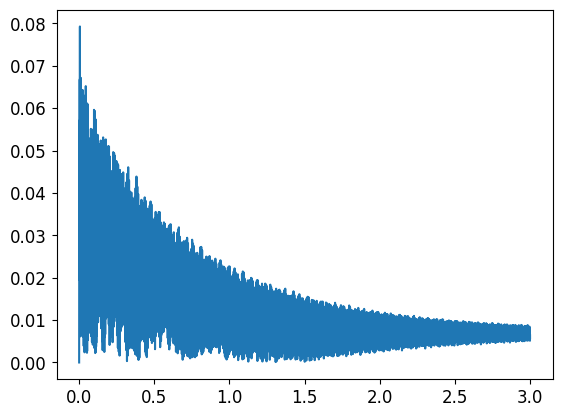

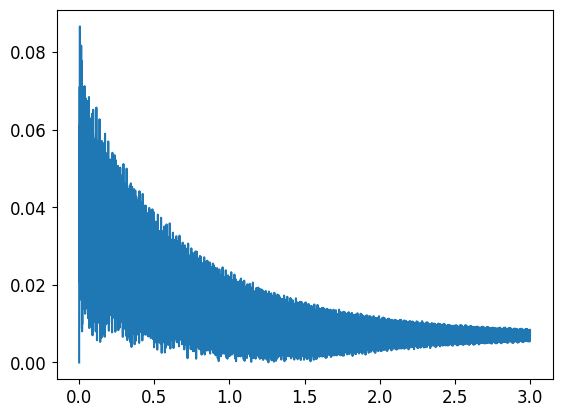

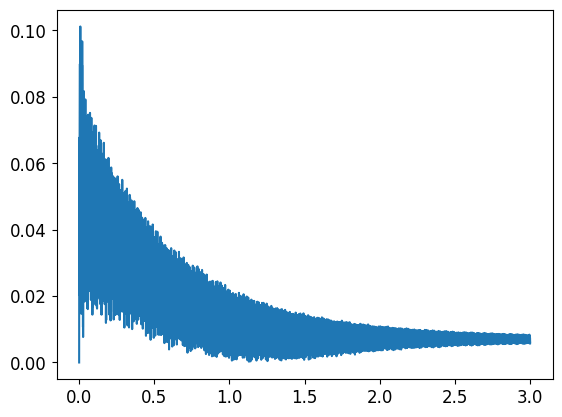

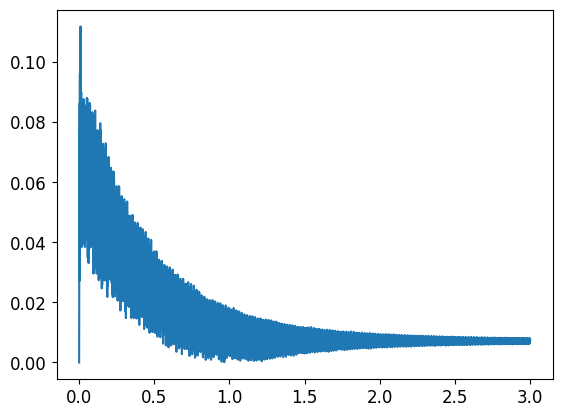

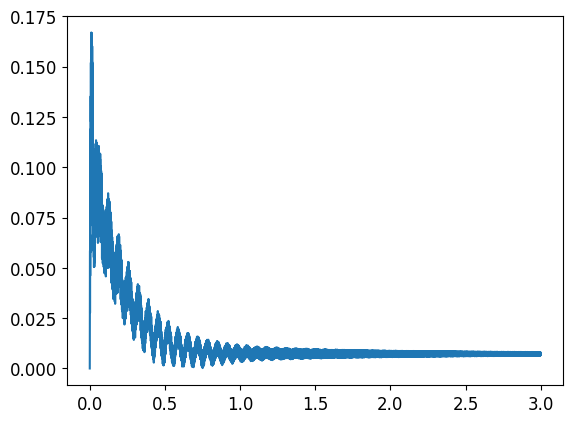

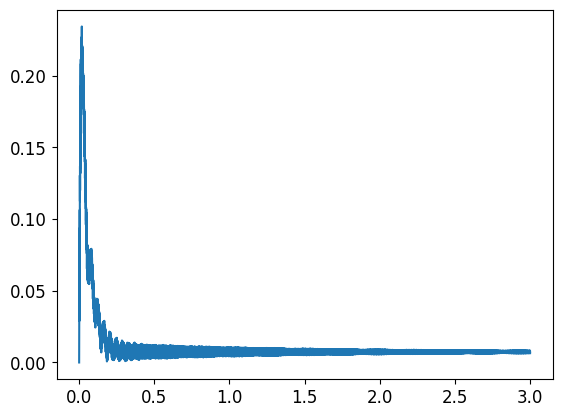

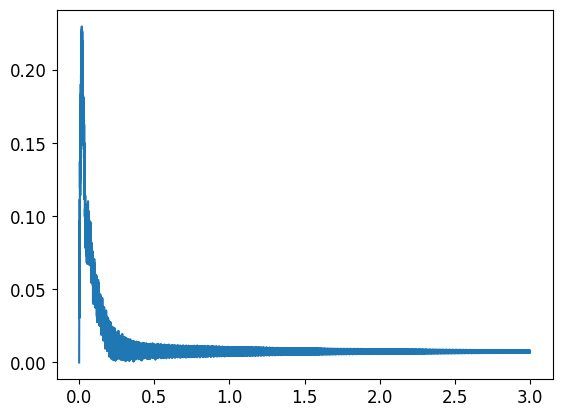

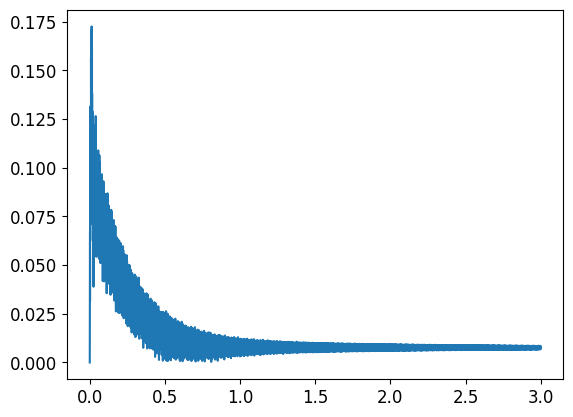

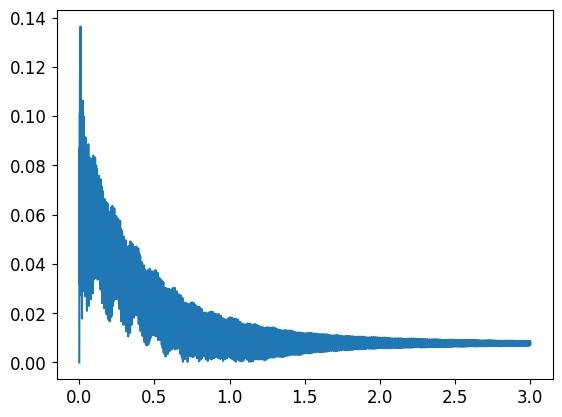

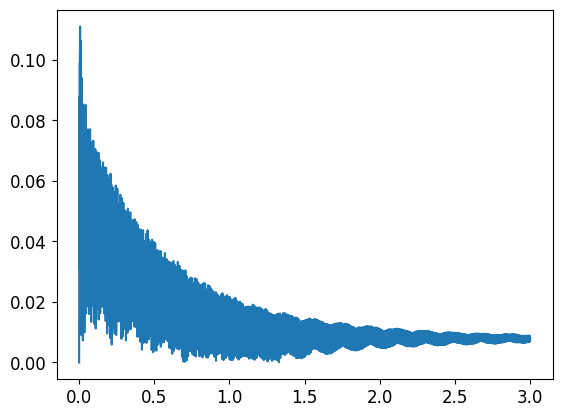

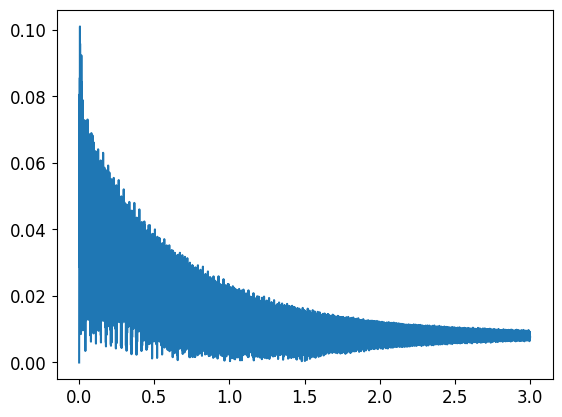

In [125]:
tmfs = []
tmf_times = []
for i in range(11):
    fig, axes = plt.subplots()
    plt.plot(t,(np.abs(output_decay_f0g1s[i].expect[-1])))
    tmf=np.abs(output_decay_f0g1s[i].expect[-1])
    tmfs.append(tmf)
    tmf_time=output_decay_f0g1s[i].expect[-1]
    tmf_times.append(tmf_time)

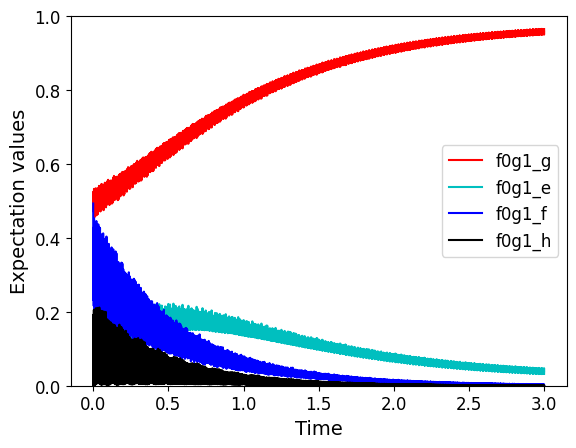

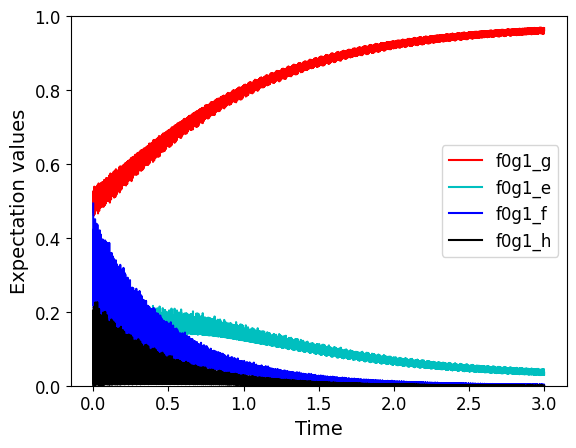

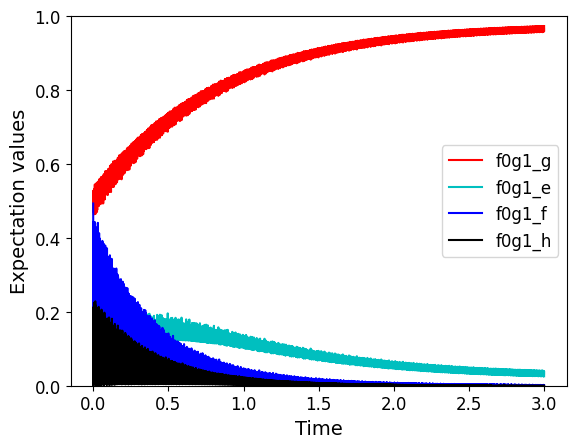

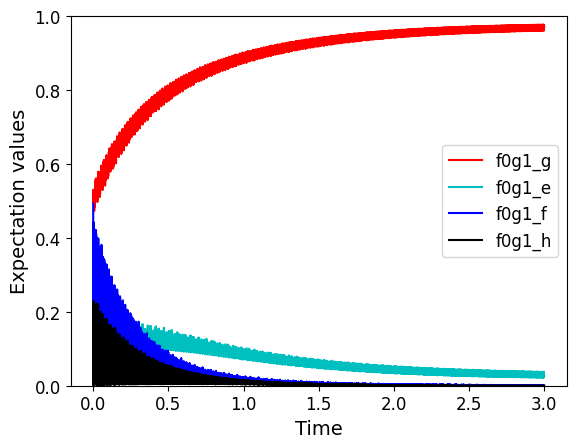

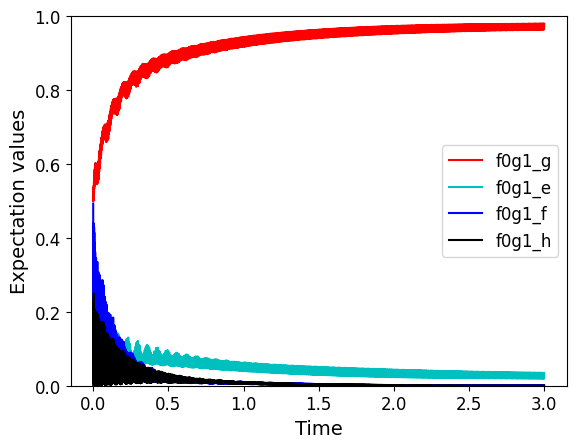

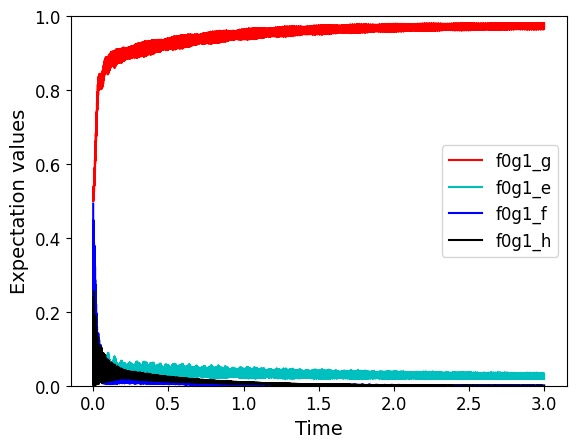

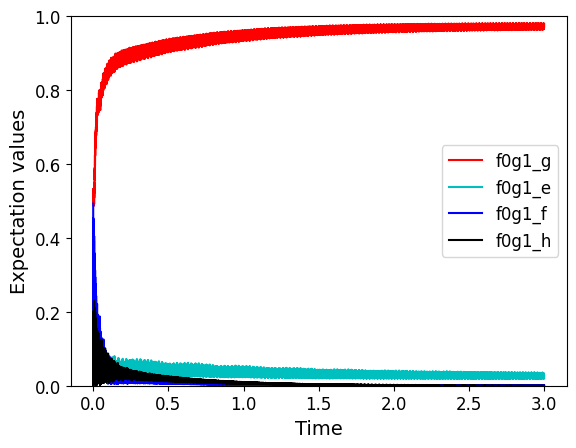

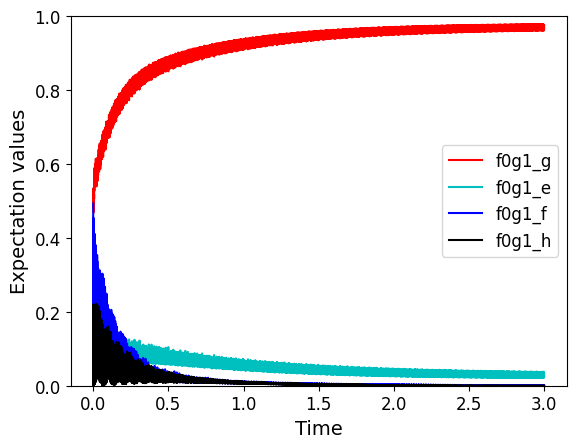

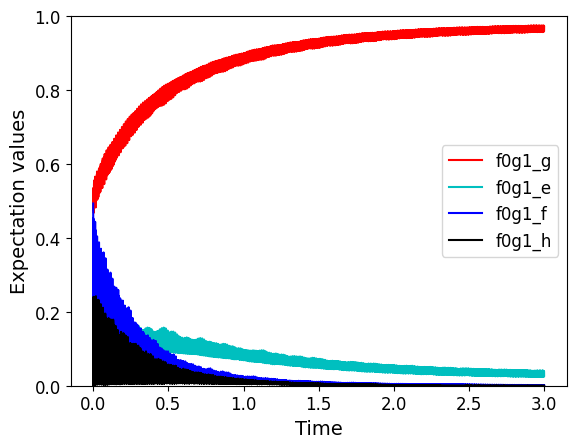

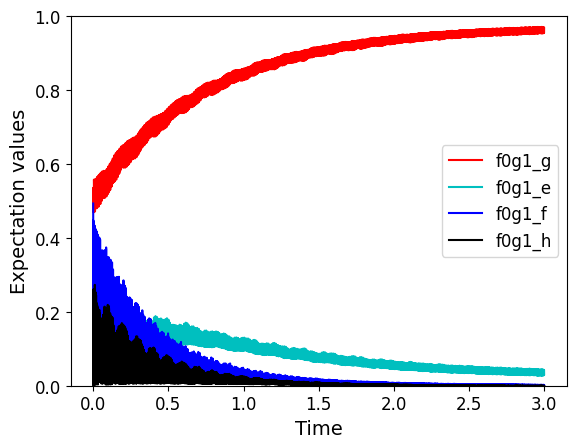

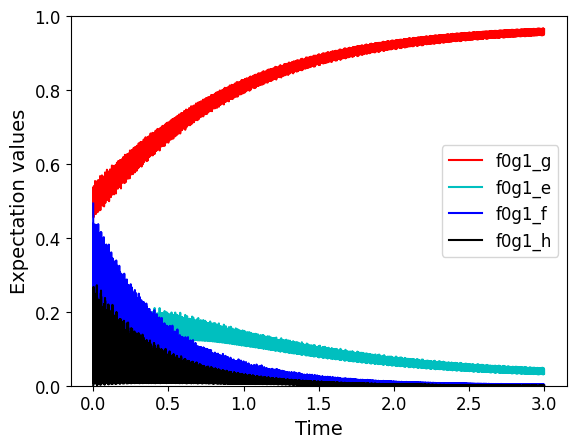

In [126]:
for i in range(11):
    fig, axes = plt.subplots()
    plt.plot(t,output_decay_f0g1s[i].expect[0],'r')
    plt.plot(t,output_decay_f0g1s[i].expect[1],'c')
    plt.plot(t,output_decay_f0g1s[i].expect[2],'b')
    plt.plot(t,output_decay_f0g1s[i].expect[3],'k')
    # plt.plot(t,output_nodecay_h0e1.expect[0],'b')
    # plt.scatter(t,output_decay_h0e1.expect[1],color='k')
    # plt.plot(t,output_nodecay_h0e1.expect[2],'c')
    # plt.scatter(t,output_decay_h0e1.expect[3],color='c')
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Expectation values', fontsize=14)
    plt.ylim(0, 1)
    plt.legend(("f0g1_g","f0g1_e","f0g1_f","f0g1_h"))

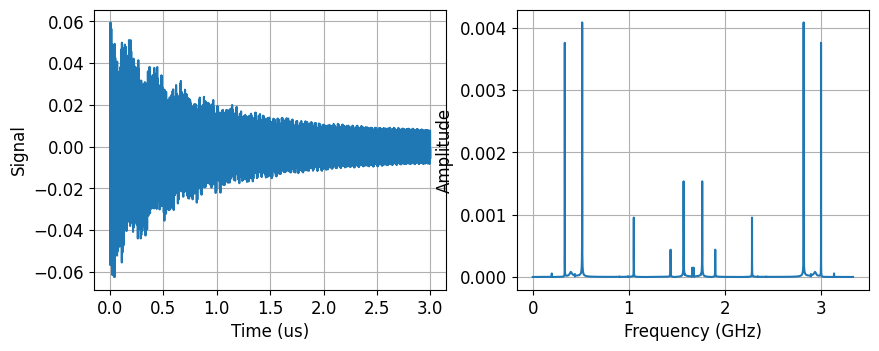

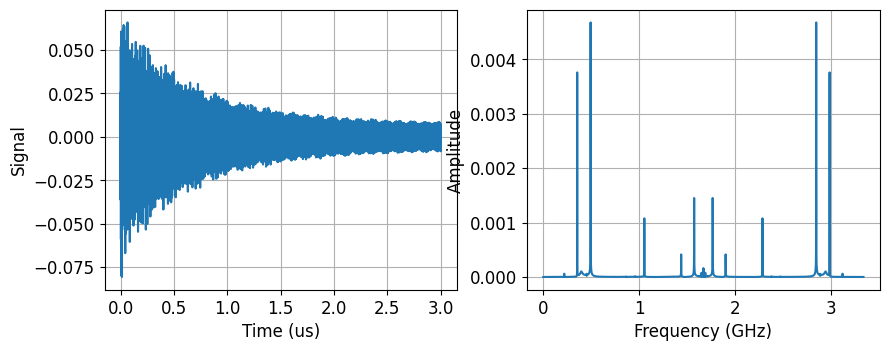

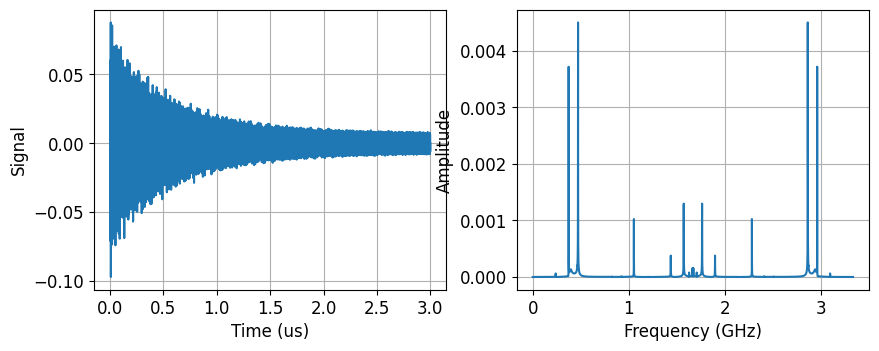

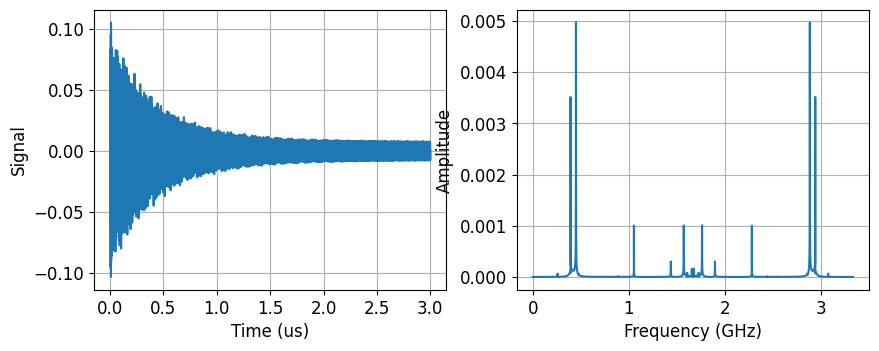

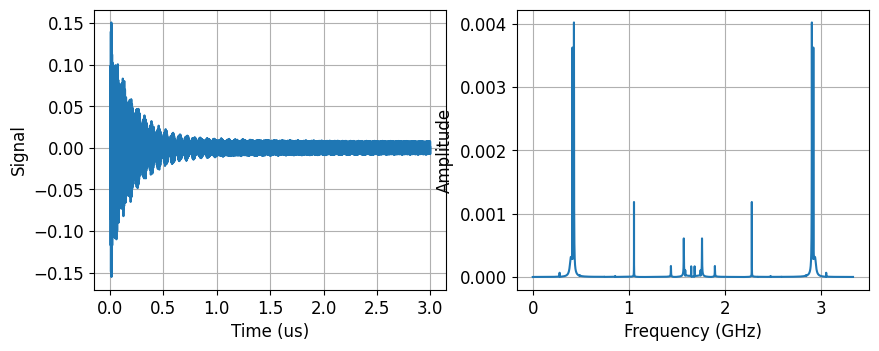

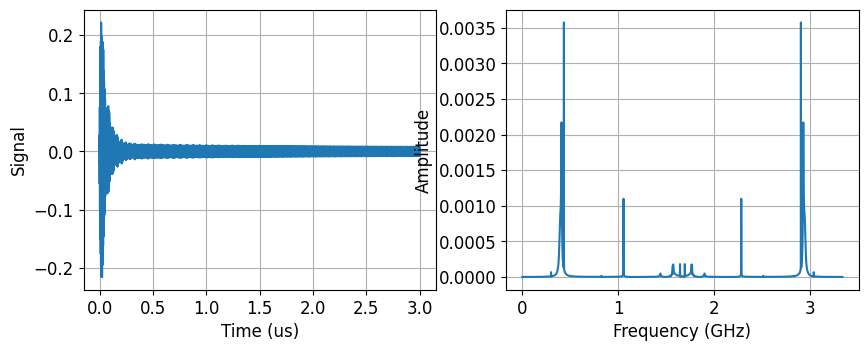

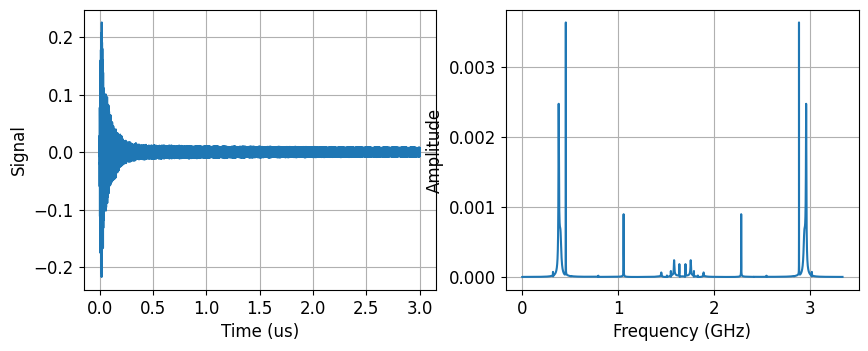

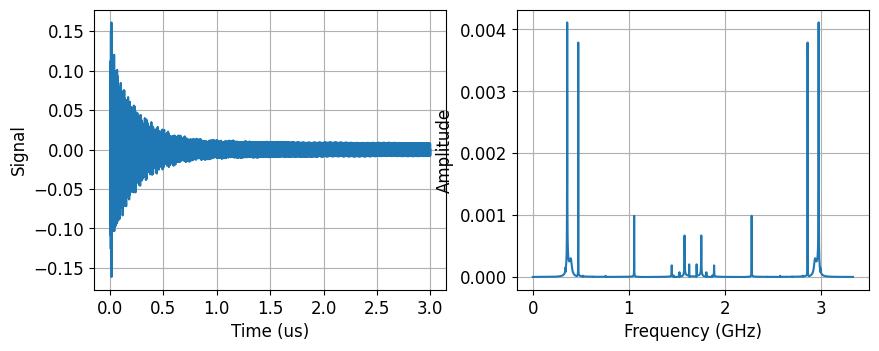

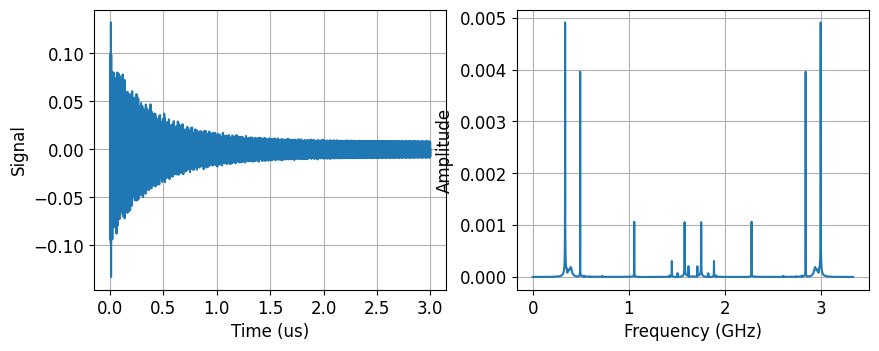

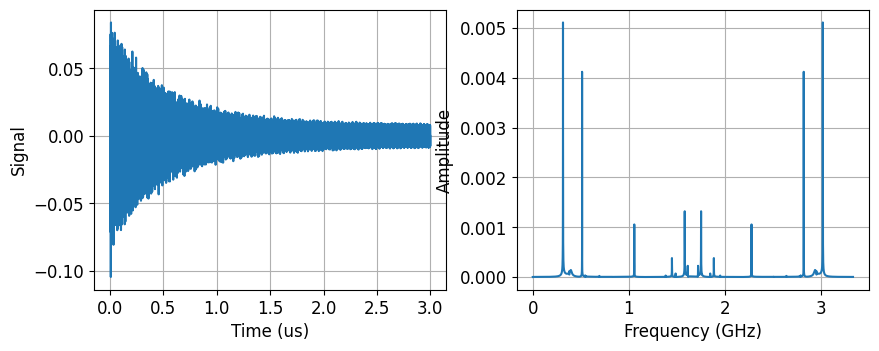

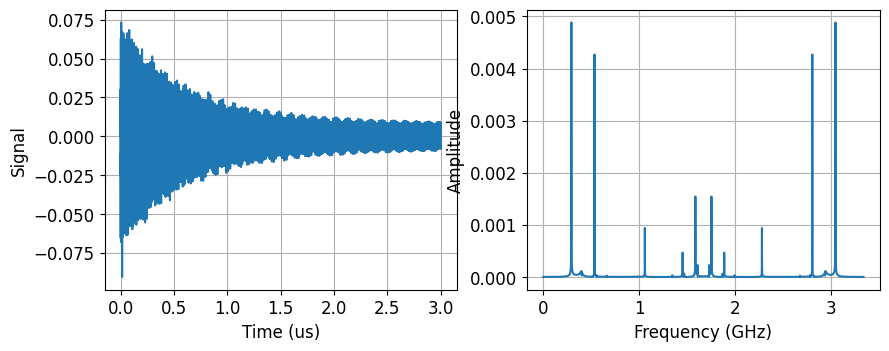

In [127]:
for i in range(11):
    # 時間信号（周波数5の正弦波 + 周波数40の正弦波）の生成
    freq = np.linspace(0, 1.0/(t[1]-t[0]), len(t))
    f3=np.real(tmf_times[i])
    # 高速フーリエ変換（周波数信号に変換）
    F3 = np.fft.fft(f3)

    # 正規化 + 交流成分2倍
    F3 = F3/(len(t)-1/2)
    F3[0] = F3[0]/2

    # グラフ表示
    fig = plt.figure(figsize=(10.0, 8.0))
    plt.rcParams['font.family'] = ' '
    plt.rcParams['font.size'] = 12

    # 時間信号（元）
    plt.subplot(221)
    plt.plot(t, f3, label='f(n)')
    plt.xlabel("Time (us)", fontsize=12)
    plt.ylabel("Signal", fontsize=12)
    plt.grid()
    # leg = plt.legend(loc=1, fontsize=15)
    # leg.get_frame().set_alpha(1)

    # 周波数信号(元)
    plt.subplot(222)
    plt.plot(freq/1000, np.abs(F3), label='|F(k)|')
    plt.xlabel('Frequency (GHz)', fontsize=12)
    plt.ylabel('Amplitude', fontsize=12)
    plt.grid()
    # leg = plt.legend(loc=1, fontsize=15)
    # leg.get_frame().set_alpha(1)

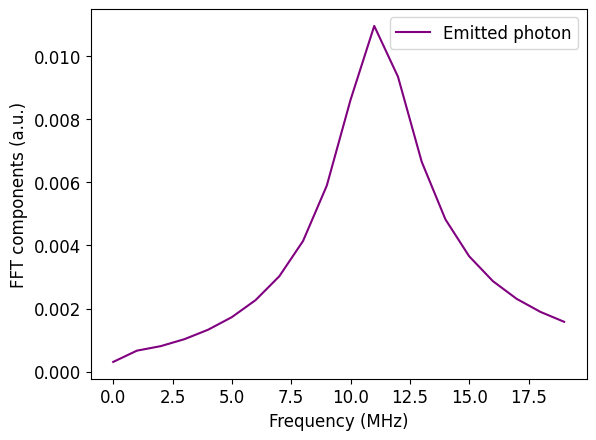

In [18]:
s1=0
s2=20
plt.plot(freq[s1:s2], np.abs(F3)[s1:s2],'purple', label='Emitted photon')
plt.xlabel('Frequency (MHz)')
plt.ylabel('FFT components (a.u.)')
plt.legend()
data_for_fit_x=freq[s1:s2]/1000
data_for_fit_y=np.abs(F3)[s1:s2]

In [18]:
## Add new virtual resonator for output
## Try for the mode function from Schordinger equation
# tmf_time->No units, need to be time with a factor of(?)
fitted_tmf=interp.interp1d(t, np.sqrt(kappa)*tmf_time,  kind='cubic')

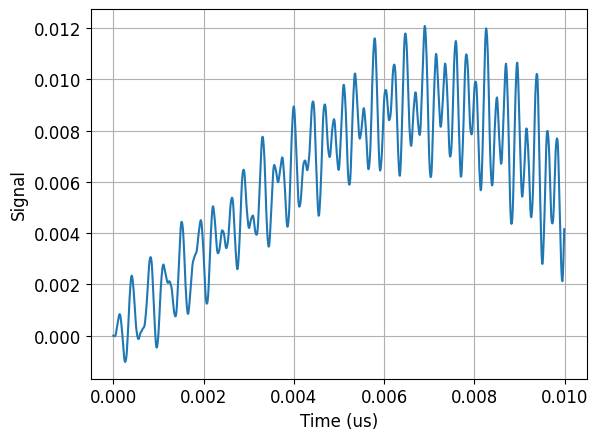

In [43]:
plt.plot(t[0:1000], f3[0:1000], label='f(n)')
plt.xlabel("Time (us)", fontsize=12)
plt.ylabel("Signal", fontsize=12)
plt.grid()


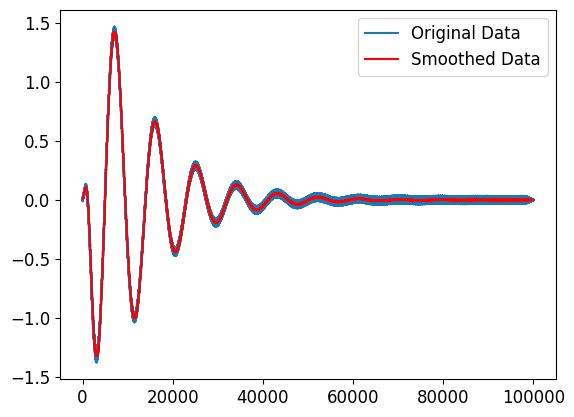

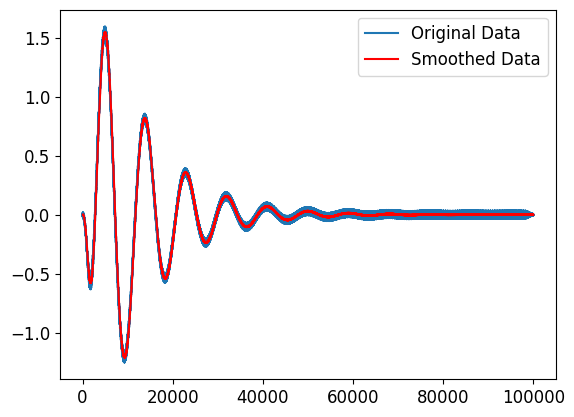

In [59]:
def moving_average(data, window_size):
    """Smooth data using a moving average."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Example usage:
data = np.sqrt(kappa)*tmf_time  # Replace this with your data
window_size = 100
smoothed_data = moving_average(data, window_size)


plt.plot(np.real(data)[0:-1], label='Original Data')
plt.plot(np.arange(window_size-1, len(data))[0:-1], np.real(smoothed_data)[0:-1], label='Smoothed Data', color='red')
plt.legend()
plt.show()

plt.plot(np.imag(data)[0:-1], label='Original Data')
plt.plot(np.arange(window_size-1, len(data))[0:-1], np.imag(smoothed_data)[0:-1], label='Smoothed Data', color='red')
plt.legend()
plt.show()

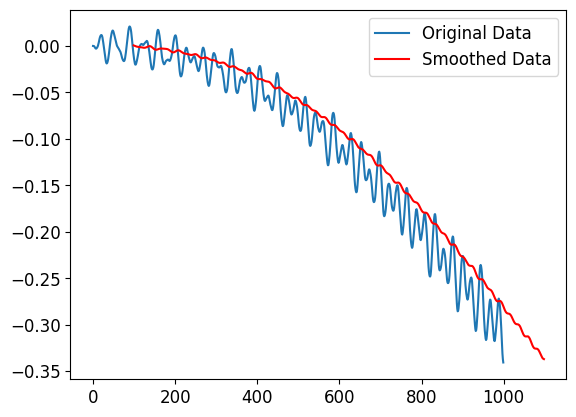

In [56]:

plt.plot(np.imag(data)[0:1000], label='Original Data')
plt.plot(np.arange(window_size-1, len(data))[0:1000], np.imag(smoothed_data)[0:1000], label='Smoothed Data', color='red')
plt.legend()
plt.show()

In [57]:
len(smoothed_data)

99902

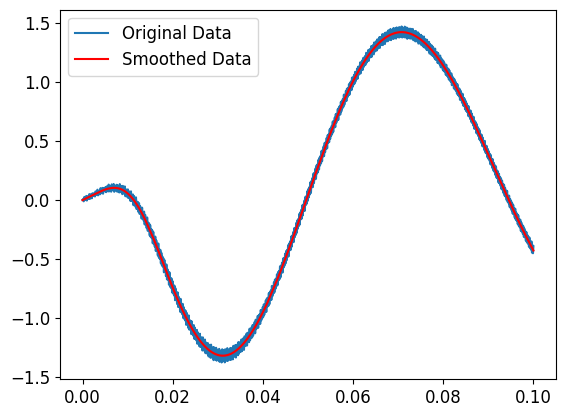

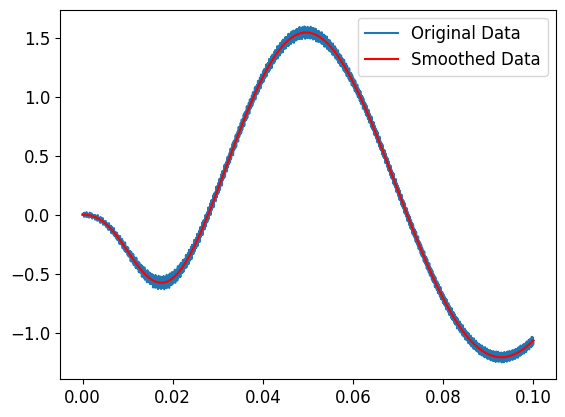

In [144]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# Example data
# data = np.random.randn(100)  # Replace this with your data

data_real = np.sqrt(kappa)*np.real(tmf_time)  # Replace this with your data
data_imag = np.sqrt(kappa)*np.imag(tmf_time)  # Replace this with your data
# Apply Savitzky-Golay filter
window_length = 500  # Choose a window length (must be odd)
polyorder = 2  # Choose the order of the polynomial
smoothed_data_real = savgol_filter(data_real, window_length, polyorder)
smoothed_data_imag = savgol_filter(data_imag, window_length, polyorder)
# Plotting the original and smoothed data

plt.plot(t[0:10000],np.real(data)[0:10000], label='Original Data')
plt.plot(t[0:10000],np.real(smoothed_data_real)[0:10000], label='Smoothed Data', color='red')
plt.legend()
plt.show()

# Plotting the original and smoothed data
plt.plot(t[0:10000],np.imag(data)[0:10000], label='Original Data')
plt.plot(t[0:10000],smoothed_data_imag[0:10000], label='Smoothed Data', color='red')
plt.legend()
plt.show()


In [77]:
smoothed_data=smoothed_data_real+1j*smoothed_data_imag
fitted_tmf=interp.interp1d(t, smoothed_data,  kind='cubic')

In [78]:
def normlize_v_tmf_se(t):
    return np.real(fitted_tmf(t).conj()*fitted_tmf(t))

In [114]:
picktime=np.linspace(0,Tf,1001)
integrate_tmp_list=np.array([normlize_v_tmf_se(picktime[cc]) for cc in range(len(picktime))]) ## |v(t)|^2

In [115]:
intgrated_tmp_list=np.cumsum(integrate_tmp_list)*picktime[1]

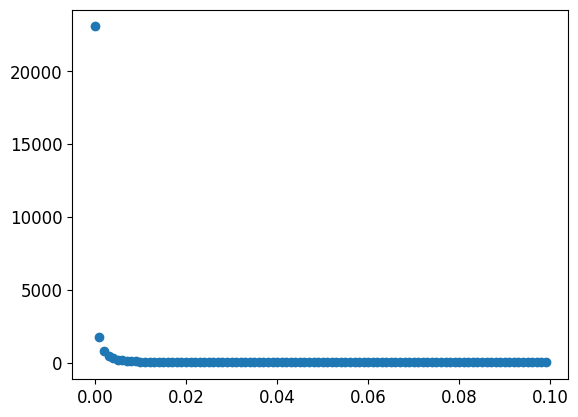

In [81]:
plt.scatter(picktime[0:100],1/np.sqrt(intgrated_tmp_list[0:100]))

In [122]:
intgrated_tmp_list[0]=0.001*intgrated_tmp_list[1]
# inteplot to get the normfunction
fitted_intgrated_tmp=interp.interp1d(picktime, intgrated_tmp_list,  kind='cubic')

0.23059051718223936

In [123]:
intgrated_tmp_list

array([3.14180028e-10, 3.14180028e-07, 1.71591222e-06, ...,
       2.30590516e-01, 2.30590517e-01, 2.30590517e-01])

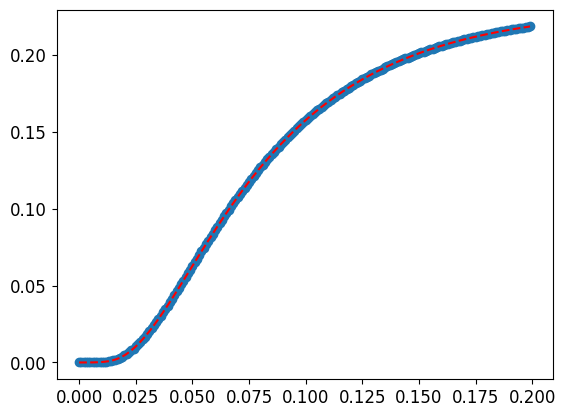

In [146]:
plt.scatter(picktime[0:200],intgrated_tmp_list[0:200])
plt.plot(picktime[0:200],fitted_intgrated_tmp(picktime)[0:200],'r--')

In [125]:
# based on the mode function to get the emitted photon state
eps=1e-8
# def out_couple_g_tmf_se(t,args):
#     # if t<0.001:
#     #     norm_v_tmf_se=integrate.quad(normlize_v_tmf_se,0,0.001)
#     # else:
#     #     norm_v_tmf_se,err_v_tmf_se=integrate.quad(normlize_v_tmf_se,0,t)
#     # return -fitted_tmf(t).conj()/np.sqrt(norm_v_tmf_se)

#     norm_v_tmf_se,err_v_tmf_se=integrate.quad(normlize_v_tmf_se,0,t)
#     return -fitted_tmf(t).conj()/np.sqrt(norm_v_tmf_se+eps)

# ## based on the mode function to get the emitted photon state
# def out_couple_g_conj_tmf_se(t,args):
#     # if t<0.001:
#     #     norm_v_tmf_se,err_v_tmf_se=integrate.quad(normlize_v_tmf_se,0,0.001)
#     # else:
#     #     norm_v_tmf_se,err_v_tmf_se=integrate.quad(normlize_v_tmf_se,0,t)
#     # return -fitted_tmf(t)/np.sqrt(norm_v_tmf_se)
#     norm_v_tmf_se,err_v_tmf_se=integrate.quad(normlize_v_tmf_se,0,t)
#     return -fitted_tmf(t)/np.sqrt(norm_v_tmf_se+eps)

    
def out_couple_g_tmf_se(t,args):
    norm_v_tmf_se=fitted_intgrated_tmp(t)
    return -fitted_tmf(t).conj()/np.sqrt(norm_v_tmf_se)

## based on the mode function to get the emitted photon state
def out_couple_g_conj_tmf_se(t,args):
    norm_v_tmf_se=fitted_intgrated_tmp(t)
    return -fitted_tmf(t)/np.sqrt(norm_v_tmf_se)

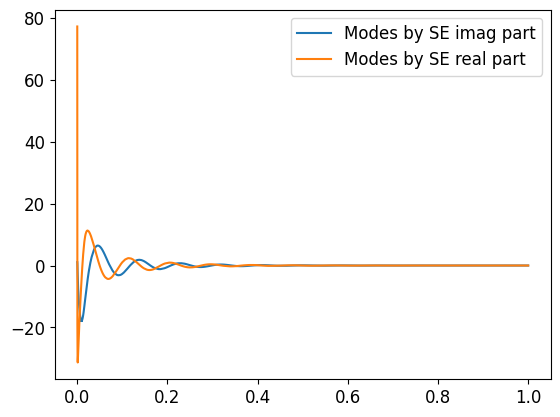

In [126]:
plt.plot(t,[np.imag(out_couple_g_tmf_se(t[cc],0)) for cc in range(len(t))],label="Modes by SE imag part")
plt.plot(t,[np.real(out_couple_g_tmf_se(t[cc],0)) for cc in range(len(t))],label="Modes by SE real part")
plt.legend()

In [129]:
## define resonator for output modes

Nout_res=3

cavobj=basis(Nout_res);
v_cav=destroy(Nout_res); # destroy
v_cavd=create(Nout_res); # create


In [236]:
## New Hamiltonian that with the resonator of out put
Hamil_virtual_out_up=1j/2*np.sqrt(kappa)*tensor(qeye(Nqu),acavd,v_cav) # *g_v().conj()
Hamil_virtual_out_down=Hamil_virtual_out_up.dag()
## new Hamiltonian with outmode
H0_with_outmode=tensor(H0,qeye(Nout_res))
H1_anni_with_outmode= tensor(H1_anni,qeye(Nout_res))
H1_crea_with_outmode= tensor(H1_crea,qeye(Nout_res))


In [237]:
H_f0g1_with_outmode_tmf_se = [H0_with_outmode,[H1_anni_with_outmode, H1_coeff_new_nRWA_f0g1_pulse_ani],[H1_crea_with_outmode, H1_coeff_new_nRWA_f0g1_pulse_crea],\
                  [Hamil_virtual_out_up,out_couple_g_conj_tmf_se],[Hamil_virtual_out_down,out_couple_g_tmf_se]]

In [238]:
##### 
def sqrtKappaExt_constant(t, args): return np.sqrt(kappa)

# c_ops_new.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav,qeye(Nout_res)))
# c_ops_new=[[(tensor(qeye(Nqu),acav,qeye(Nout_res)),sqrtKappaExt_constant),\
#             (tensor(qeye(Nqu),qeye(Nres),v_cav), out_couple_g_conj)]]

c_ops_new_tmf_se=[[(tensor(qeye(Nqu),acav,qeye(Nout_res)),sqrtKappaExt_constant),\
            (tensor(qeye(Nqu),qeye(Nres),v_cav), out_couple_g_conj_tmf_se)]]
## qubit-resonator coupling strength
gqcav=2*np.pi*150;

## Qubit have an intrisc infinite lifetime
inflifetime=1;
if inflifetime:
    print("Qubit lifetime infinity, despite Purcell")
    gammaT1ge=0;
    gammaTphige=0;
    gammaT1ef=0;
    gammaTphief=0;
    gammaT1fh=0;
    gammaTphifh=0;
    # T1geapprox=1/(kappa*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter)**2-cfcoupling**2)**2)*(1+gqcav**2/2/((omegaq-omegafilter)-cfcoupling)**2+gqcav**2/2/((omegaq-omegafilter)+cfcoupling)**2)
    # T1efapprox=1/(kappa*2*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+aharmon)**2-cfcoupling**2)**2)*(1+gqcav**2/((omegaq-omegafilter+aharmon)-cfcoupling)**2+gqcav**2/((omegaq-omegafilter+aharmon)+cfcoupling)**2)
    # T1fhapprox=1/(kappa*3*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+2*aharmon)**2-cfcoupling**2)**2)*(1+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)-cfcoupling)**2+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)+cfcoupling)**2)
    # T2geapprox=2*T1geapprox
    # T2efapprox=2*T1efapprox
    # T2fhapprox=2*T1fhapprox
    # keffres=4*cfcoupling**2/kappa/2/np.pi
    chieff=np.abs(1/2/np.pi*2*gqcav**2*aharmon/(omegaq-omegares)/(omegaq-omegares+aharmon))
    # print("T1ge(us)="+str(T1geapprox))
    # print("T1ef(us)="+str(T1efapprox))
    # print("T1fh(us)="+str(T1fhapprox))
    # print("T2ge(us)="+str(T2geapprox))
    # print("T2ef(us)="+str(T2efapprox))
    # print("T2fh(us)="+str(T2fhapprox))
    # print("kappa_eff_res/2pi(MHz)="+str(keffres))
    print("chi_eff/2pi(MHz)="+str(chieff))
    # c_ops_new=[];
    # c_ops_new.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav,qeye(Nout_res)))
else:
    print("Qubit lifetime has been defined")
    T1geapprox=15
    T1efapprox=12
    T1fhapprox=3
    T2geapprox=15
    T2efapprox=5
    T2fhapprox=0.5
    gammaT1ge=1/T1geapprox-(kappa*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter)**2-cfcoupling**2)**2)*(1+gqcav**2/2/((omegaq-omegafilter)-cfcoupling)**2+gqcav**2/2/((omegaq-omegafilter)+cfcoupling)**2);
    gammaTphige=(1/T2geapprox-1/T1geapprox/2)/2;
    gammaT1ef=1/T1efapprox-(kappa*2*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+aharmon)**2-cfcoupling**2)**2)*(1+gqcav**2/((omegaq-omegafilter+aharmon)-cfcoupling)**2+gqcav**2/((omegaq-omegafilter+aharmon)+cfcoupling)**2);
    gammaTphief=(1/T2efapprox-1/T1efapprox/2)/2;
    gammaT1fh=1/T1fhapprox-(kappa*3*gqcav**2*(cfcoupling)**2/((omegaq-omegafilter+2*aharmon)**2-cfcoupling**2)**2)*(1+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)-cfcoupling)**2+3/2*gqcav**2/((omegaq-omegafilter+2*aharmon)+cfcoupling)**2);
    gammaTphifh=(1/T2fhapprox-1/T1fhapprox/2)/2;
    keffres=4*cfcoupling**2/kappa/2/np.pi
    chieff=np.abs(1/2/np.pi*2*gqcav**2*aharmon/(omegaq-omegafilter)/(omegaq-omegafilter+aharmon))
    print("T1ge(us)="+str(T1geapprox))
    print("T1ef(us)="+str(T1efapprox))
    print("T1fh(us)="+str(T1fhapprox))
    print("T2ge(us)="+str(T2geapprox))
    print("T2ef(us)="+str(T2efapprox))
    print("T2fh(us)="+str(T2fhapprox))
    print("kappa_eff_res/2pi(MHz)="+str(keffres))
    print("chi_eff/2pi(MHz)="+str(chieff))
    # c_ops_new=[];
    # c_ops_new.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav,qeye(Nout_res)))
    c_ops_new.append(np.sqrt(gammaT1ge)*tensor(gedecayop,qeye(Nres),qeye(Nout_res)))
    c_ops_new.append(np.sqrt(gammaT1ef)*tensor(efdecayop,qeye(Nres),qeye(Nout_res)))
    c_ops_new.append(np.sqrt(gammaT1fh)*tensor(fhdecayop,qeye(Nres),qeye(Nout_res)))
    c_ops_new.append(np.sqrt(gammaTphige)*tensor(gedechoop,qeye(Nres),qeye(Nout_res)))
    c_ops_new.append(np.sqrt(gammaTphief)*tensor(efdechoop,qeye(Nres),qeye(Nout_res)))
    c_ops_new.append(np.sqrt(gammaTphifh)*tensor(fhdechoop,qeye(Nres),qeye(Nout_res)))

Qubit lifetime infinity, despite Purcell
chi_eff/2pi(MHz)=3.749999999999997


In [239]:
# H1= 0.5*tensor(bqub+bqubd,qeye(Nres),qeye(Nfilter))
t_new=np.linspace(0,0.99995,20000)
testinitialstate=tensor((initialstatef0+initialstateg0),basis(Nout_res)).unit()

In [240]:
output_decay_f0g1_with_outmode_tmf_se = mesolve(H_f0g1_with_outmode_tmf_se,testinitialstate, t_new, c_ops=c_ops_new_tmf_se,progress_bar=True)

10.0%. Run time:  44.98s. Est. time left: 00:00:06:44
20.0%. Run time:  98.13s. Est. time left: 00:00:06:32
30.0%. Run time: 152.07s. Est. time left: 00:00:05:54
40.0%. Run time: 206.43s. Est. time left: 00:00:05:09
50.0%. Run time: 265.21s. Est. time left: 00:00:04:25
60.0%. Run time: 331.21s. Est. time left: 00:00:03:40
70.0%. Run time: 402.79s. Est. time left: 00:00:02:52
80.0%. Run time: 480.43s. Est. time left: 00:00:02:00
90.0%. Run time: 563.05s. Est. time left: 00:00:01:02
Total run time: 649.04s


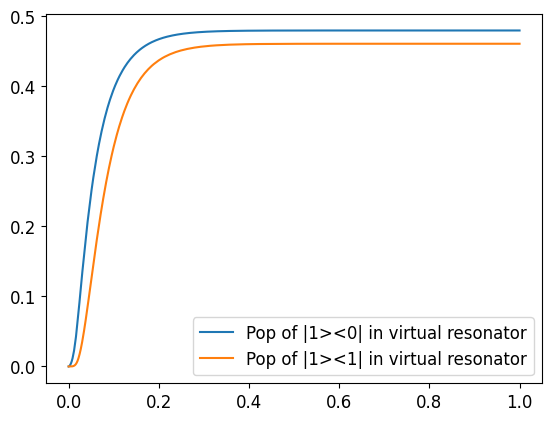

In [241]:
# plt.plot([np.abs(output_decay_f0g1_with_outmode.states[cc].ptrace(2)[1,1]) for cc in range(len(t_new))])
plt.plot(t_new,[np.abs(output_decay_f0g1_with_outmode_tmf_se.states[cc].ptrace(2)[0,1]) for cc in range(len(t_new))],label="Pop of |1><0| in virtual resonator")
plt.plot(t_new,[np.abs(output_decay_f0g1_with_outmode_tmf_se.states[cc].ptrace(2)[1,1]) for cc in range(len(t_new))],label="Pop of |1><1| in virtual resonator")

plt.legend()

In [242]:
[np.abs(output_decay_f0g1_with_outmode_tmf_se.states[-1].ptrace(2)[0,1]),\
 np.abs(output_decay_f0g1_with_outmode_tmf_se.states[-1].ptrace(2)[1,1])]

[0.4799373544947514, 0.46097947142331536]

[[5.39021182e-01 4.79937354e-01 3.98582741e-05]
 [4.79937354e-01 4.60979471e-01 3.90394772e-05]
 [3.98582741e-05 3.90394772e-05 6.53566147e-07]]
[[ 5.39021182e-01+1.67653320e-16j  4.79937261e-01-2.98817917e-04j
  -3.98150785e-05+1.85513887e-06j]
 [ 4.79937261e-01+2.98817917e-04j  4.60979471e-01-1.73474091e-16j
  -3.89996087e-05+1.76388701e-06j]
 [-3.98150785e-05-1.85513887e-06j -3.89996087e-05-1.76388701e-06j
  -6.53566147e-07-8.79198525e-19j]]


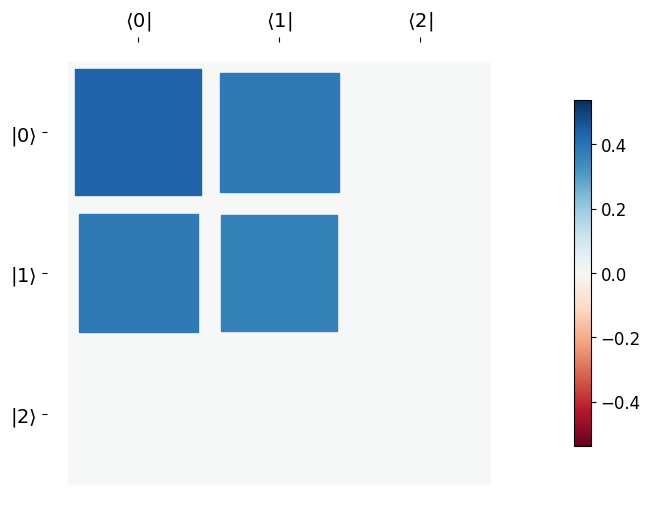

In [243]:
hinton(output_decay_f0g1_with_outmode_tmf_se.states[-1].ptrace(2))
print(np.abs(output_decay_f0g1_with_outmode_tmf_se.states[-1].ptrace(2).full()))
print(output_decay_f0g1_with_outmode_tmf_se.states[-1].ptrace(2).full())

In [244]:
np.trace(Qobj(np.abs(output_decay_f0g1_with_outmode_tmf_se.states[-1].ptrace(2).full()))*\
         Qobj([[1,1,0],[1,1,0],[0,0,0]]).unit())

(0.9799376812778509+0j)

In [139]:
## calculate the mode loss
def L_operator(t):
    L_operator_tmp=tensor(qeye(Nqu),acav,qeye(Nout_res))*sqrtKappaExt_constant(t,t)+\
            tensor(qeye(Nqu),qeye(Nres),v_cav)*out_couple_g_conj_tmf_se(t,t)
    return L_operator_tmp


In [140]:
loss_modes_list=[expect(L_operator(t_new[id]).dag()*L_operator(t_new[id]),output_decay_f0g1_with_outmode_tmf_se.states[id]) for id in range(len(t_new))]

Total loss = 0.05844834198420689


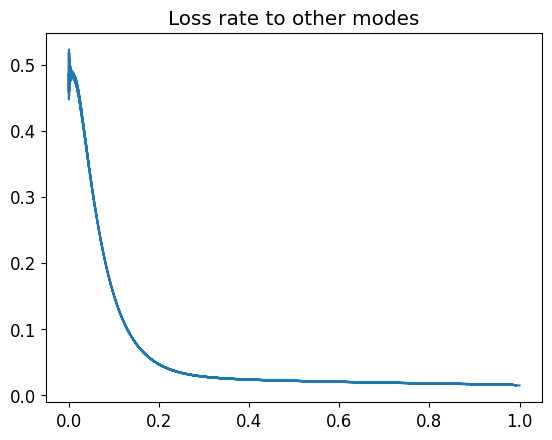

In [141]:
plt.plot(t_new,loss_modes_list)
plt.title("Loss rate to other modes")
print("Total loss = "+str(np.sum(loss_modes_list)*t_new[1]))

In [142]:
loss_modes_tot_list=np.cumsum(loss_modes_list)*t_new[1]

Total loss = 0.05844834198420689


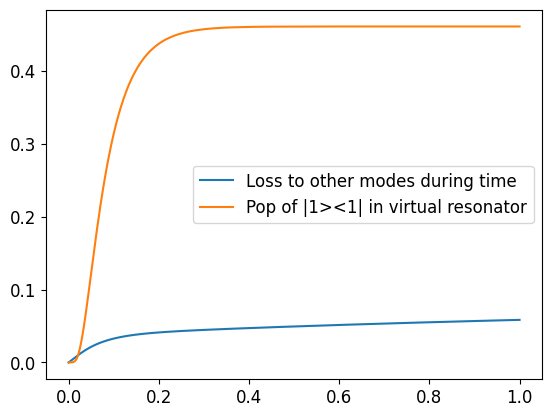

In [143]:
plt.plot(t_new,loss_modes_tot_list,label="Loss to other modes during time")
plt.plot(t_new,[np.abs(output_decay_f0g1_with_outmode_tmf_se.states[cc].ptrace(2)[1,1]) for cc in range(len(t_new))],label="Pop of |1><1| in virtual resonator")
plt.legend()
print("Total loss = "+str(np.sum(loss_modes_list)*t_new[1]))

In [ ]:
## Fock 1 state

In [147]:
# H1= 0.5*tensor(bqub+bqubd,qeye(Nres),qeye(Nfilter))
t_new=np.linspace(0,0.99995,20000)
testinitialstate=tensor((initialstatef0),basis(Nout_res)).unit()

In [148]:
output_decay_f0g1_with_outmode_tmf_se_fock1 = mesolve(H_f0g1_with_outmode_tmf_se,testinitialstate, t_new, c_ops=c_ops_new_tmf_se,progress_bar=True)

10.0%. Run time:  46.28s. Est. time left: 00:00:06:56
20.0%. Run time:  98.31s. Est. time left: 00:00:06:33
30.0%. Run time: 151.03s. Est. time left: 00:00:05:52
40.0%. Run time: 201.66s. Est. time left: 00:00:05:02
50.0%. Run time: 254.47s. Est. time left: 00:00:04:14
60.0%. Run time: 311.38s. Est. time left: 00:00:03:27
70.0%. Run time: 371.92s. Est. time left: 00:00:02:39
80.0%. Run time: 436.63s. Est. time left: 00:00:01:49
90.0%. Run time: 506.08s. Est. time left: 00:00:00:56
Total run time: 579.33s


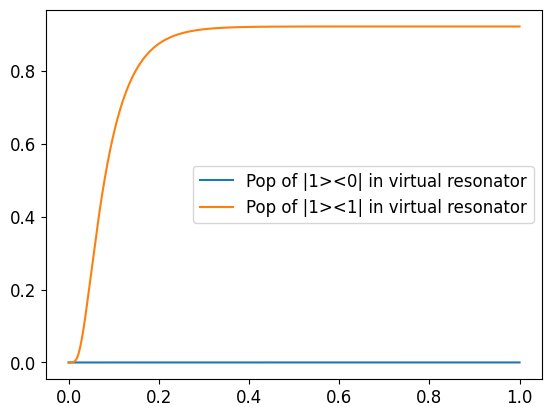

In [149]:
# plt.plot([np.abs(output_decay_f0g1_with_outmode.states[cc].ptrace(2)[1,1]) for cc in range(len(t_new))])
plt.plot(t_new,[np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[cc].ptrace(2)[0,1]) for cc in range(len(t_new))],label="Pop of |1><0| in virtual resonator")
plt.plot(t_new,[np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[cc].ptrace(2)[1,1]) for cc in range(len(t_new))],label="Pop of |1><1| in virtual resonator")

plt.legend()

In [150]:
[np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[-1].ptrace(2)[0,1]),\
 np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[-1].ptrace(2)[1,1])]

[9.163098518385671e-05, 0.9219985943332849]

[[7.80025796e-02 9.16309852e-05 6.23353788e-09]
 [9.16309852e-05 9.21998594e-01 7.56850855e-05]
 [6.23353789e-09 7.56850855e-05 1.17396572e-06]]
[[ 7.80025796e-02-6.79129672e-16j  9.15749347e-05+3.20449270e-06j
  -6.22717125e-09-2.81660682e-10j]
 [ 9.15749347e-05-3.20449270e-06j  9.21998594e-01+7.27843213e-16j
  -7.55920443e-05+3.75166739e-06j]
 [-6.22717125e-09+2.81660681e-10j -7.55920443e-05-3.75166739e-06j
  -1.17396572e-06-9.29529349e-20j]]


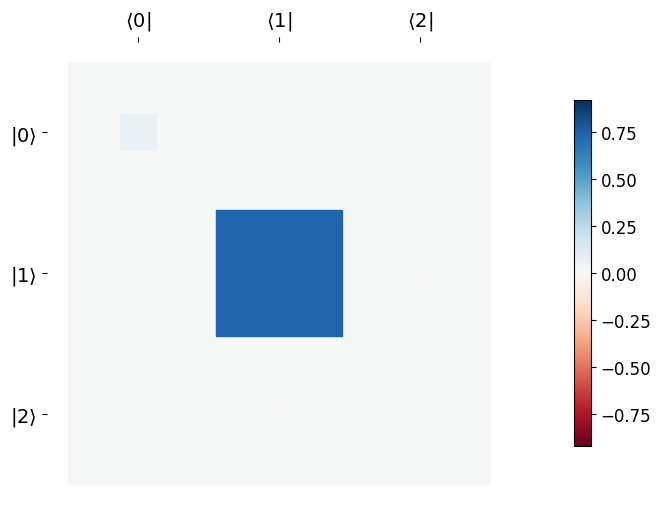

In [151]:
hinton(output_decay_f0g1_with_outmode_tmf_se_fock1.states[-1].ptrace(2))
print(np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[-1].ptrace(2).full()))
print(output_decay_f0g1_with_outmode_tmf_se_fock1.states[-1].ptrace(2).full())

In [152]:
np.trace(Qobj(np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[-1].ptrace(2).full()))*\
         Qobj([[0,0,0],[0,1,0],[0,0,0]]).unit())

(0.9219985943332849+0j)

In [139]:
## calculate the mode loss
def L_operator(t):
    L_operator_tmp=tensor(qeye(Nqu),acav,qeye(Nout_res))*sqrtKappaExt_constant(t,t)+\
            tensor(qeye(Nqu),qeye(Nres),v_cav)*out_couple_g_conj_tmf_se(t,t)
    return L_operator_tmp


In [153]:
loss_modes_list=[expect(L_operator(t_new[id]).dag()*L_operator(t_new[id]),output_decay_f0g1_with_outmode_tmf_se_fock1.states[id]) for id in range(len(t_new))]

Total loss = 0.1156538622849814


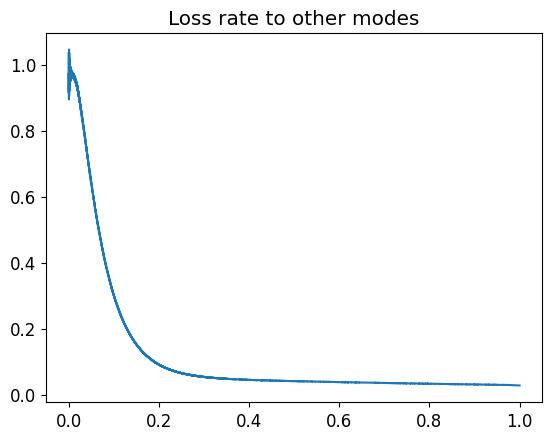

In [154]:
plt.plot(t_new,loss_modes_list)
plt.title("Loss rate to other modes")
print("Total loss = "+str(np.sum(loss_modes_list)*t_new[1]))

In [155]:
loss_modes_tot_list=np.cumsum(loss_modes_list)*t_new[1]

Total loss = 0.1156538622849814


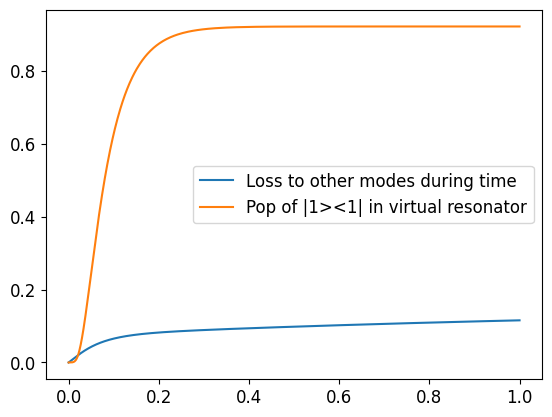

In [156]:
plt.plot(t_new,loss_modes_tot_list,label="Loss to other modes during time")
plt.plot(t_new,[np.abs(output_decay_f0g1_with_outmode_tmf_se_fock1.states[cc].ptrace(2)[1,1]) for cc in range(len(t_new))],label="Pop of |1><1| in virtual resonator")
plt.legend()
print("Total loss = "+str(np.sum(loss_modes_list)*t_new[1]))

In [164]:
testinitialstate=(initialstatef0+initialstateg0).unit()
H_f0g1 = [H0,[H1_anni, H1_coeff_new_nRWA_f0g1_pulse_ani],[H1_crea, H1_coeff_new_nRWA_f0g1_pulse_crea]]

In [165]:
output_decay_f0g1_state = mesolve(H_f0g1,testinitialstate, t, c_ops,progress_bar=True)
# gf_no_decay = mesolve(Hgf,testinitialstate, t,progress_bar=True)

10.0%. Run time:   1.68s. Est. time left: 00:00:00:15
20.0%. Run time:   3.04s. Est. time left: 00:00:00:12
30.0%. Run time:   4.20s. Est. time left: 00:00:00:09
40.0%. Run time:   5.28s. Est. time left: 00:00:00:07
50.0%. Run time:   6.55s. Est. time left: 00:00:00:06
60.0%. Run time:   7.72s. Est. time left: 00:00:00:05
70.0%. Run time:   8.91s. Est. time left: 00:00:00:03
80.0%. Run time:  10.09s. Est. time left: 00:00:00:02
90.0%. Run time:  11.45s. Est. time left: 00:00:00:01
Total run time:  12.67s


In [169]:
## Calculate the correlation matrix by hand (Lack of freq components? To many time points, take too much time)
pickuptime=np.linspace(0,Tf,101)
pickupstep=pickuptime[1]
time_ratio=round(pickupstep/t[1])
print("Pick up time ratio = "+str(time_ratio))
print("Max Freq = "+str(1.0/(pickuptime[1]-pickuptime[0])/2/1000)+" GHz")

Pick up time ratio = 1000
Max Freq = 0.05 GHz


In [170]:
pickupstates=[]
idx_pick=0
for idx_pick in range(len(pickuptime)):
    pickupstates.append(output_decay_f0g1_state.states[idx_pick*time_ratio])
print(len(pickupstates))

101


In [171]:
init_Oplist=[]
for idx_pick in range(len(pickuptime)):
    init_Op=tensor(qeye(Nqu),acav)*pickupstates[idx_pick]
    init_Oplist.append(init_Op)

In [172]:
## calculate the time evolution of V(t+t',t){Op*V(t,0){rho}}
evotime=np.flip(pickuptime)
g_corr_off_diag=[]
## calculate off diagnol term of correlation function
for idx_evo in range(len(evotime)-1):
    print("start idex="+str(idx_evo))
    time_start=time.time()
    tmp_initial_state=init_Oplist[idx_evo]
    timelist_tmp=np.linspace(pickuptime[idx_evo],Tf,round((Tf-pickuptime[idx_evo])/(t[1]))+1)
    output_decay_f0g1_state_tmp = mesolve(H_f0g1,tmp_initial_state, timelist_tmp, c_ops, progress_bar=True)
    pickup_num_tmp=len(evotime)-1-idx_evo
    g_tmp=[]
    for cc in range(pickup_num_tmp):
        state_pick_tmp=output_decay_f0g1_state_tmp.states[(cc+1)*time_ratio]
        g_corr=np.trace(tensor(qeye(Nqu),acavd)*state_pick_tmp)
        g_tmp.append(g_corr)
    g_corr_off_diag.append(g_tmp)
    time_end=time.time()
    print("caled correlation func num="+str(len(g_tmp)))
    print("finish idex="+str(idx_evo)+" with time="+str(time_end-time_start))
    # pickup_final_state=
    # print(pickup_num_tmp)

start idex=0
10.0%. Run time:   1.37s. Est. time left: 00:00:00:12
20.0%. Run time:   2.66s. Est. time left: 00:00:00:10
30.0%. Run time:   3.94s. Est. time left: 00:00:00:09
40.0%. Run time:   5.19s. Est. time left: 00:00:00:07
50.0%. Run time:   6.41s. Est. time left: 00:00:00:06
60.0%. Run time:   7.89s. Est. time left: 00:00:00:05
70.0%. Run time:   9.11s. Est. time left: 00:00:00:03
80.0%. Run time:  10.32s. Est. time left: 00:00:00:02
90.0%. Run time:  11.51s. Est. time left: 00:00:00:01
Total run time:  12.72s
caled correlation func num=100
finish idex=0 with time=12.807580471038818
start idex=1
10.0%. Run time:   1.74s. Est. time left: 00:00:00:15
20.0%. Run time:   3.32s. Est. time left: 00:00:00:13
30.0%. Run time:   4.78s. Est. time left: 00:00:00:11
40.0%. Run time:   6.18s. Est. time left: 00:00:00:09
50.0%. Run time:   7.71s. Est. time left: 00:00:00:07
60.0%. Run time:   9.35s. Est. time left: 00:00:00:06
70.0%. Run time:  10.70s. Est. time left: 00:00:00:04
80.0%. Run t

In [180]:
g_corr_diag=[]
for idx_pick in range(len(pickuptime)):
    tmp_g_diag=np.trace(tensor(qeye(Nqu),acav).dag()*tensor(qeye(Nqu),acav)*pickupstates[idx_pick])
    g_corr_diag.append(tmp_g_diag)

In [181]:
g_corr_matrix=np.zeros([len(pickuptime),len(pickuptime)],dtype=complex)

In [182]:
g_corr_matrix=np.zeros([len(pickuptime),len(pickuptime)],dtype=complex)
for cc in range(len(pickuptime)):
    for ii in range(len(pickuptime)):
        if ii<cc:
            g_corr_matrix[cc,ii]=g_corr_off_diag[ii][cc-ii-1].conj()
        elif ii==cc:
            g_corr_matrix[cc,ii]=g_corr_diag[cc]
        elif ii>cc:
            g_corr_matrix[cc,ii]=g_corr_off_diag[cc][ii-cc-1]          

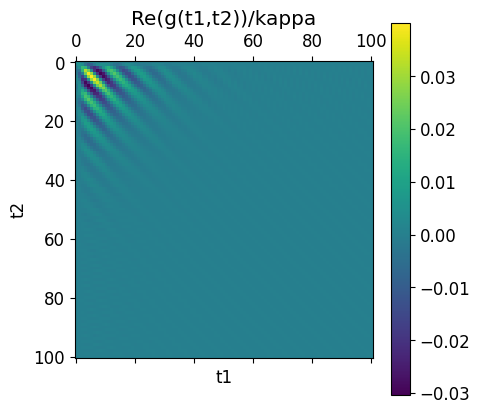

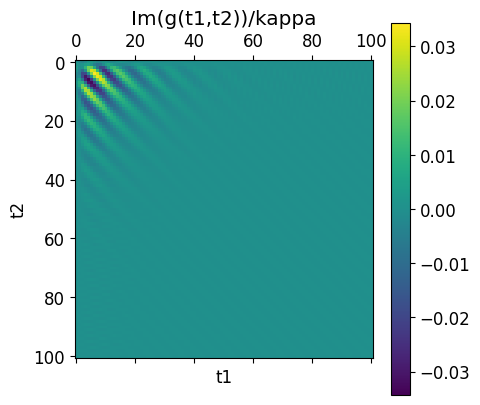

In [184]:
plt.matshow(np.real(g_corr_matrix))
plt.xlabel("t1")
plt.ylabel("t2")
plt.colorbar()
plt.title("Re(g(t1,t2))/kappa")
plt.show()
plt.matshow(np.imag(g_corr_matrix))
plt.xlabel("t1")
plt.ylabel("t2")
plt.colorbar()
plt.title("Im(g(t1,t2))/kappa")
plt.show()

In [221]:
def highestEigFuncs(tList, g1, nMax=10, plotAll=False, plotAbs=False, plotImag=True, returnFuncs=True):
    
    #diagonalize
    eigvals, eigvecs = scipy.linalg.eigh(g1, type=1)
    
    #normalize eigenvalues
    #eigvals = (eigvals**2)/(np.sum(eigvals**2))
    print('eivals sum before normalization is ', np.sum(eigvals))
    eigvals = eigvals/(np.sum(eigvals))
    print('eivals sum is ', np.sum(eigvals))
    print('eivals sum squared is ', np.sum(eigvals**2))
    
    noRows = int(np.shape(g1)[0]/10)
    print('noRows =  ', noRows)
   
    
    if plotAll:
        fig4, axes4 = plt.subplots(noRows,2, figsize=(20,300))
        fig4.suptitle('Before Sorting') 
        for i in range(noRows):

            for k in range(10):
                axes4[i][0].plot(np.real(eigvecs[:,10*i+k]), label='eigVal#'+str(10*i+k)+'_'+str(eigvals[i]))
                axes4[i][1].plot(np.imag(eigvecs[:,10*i+k]), label='eigVal#'+str(10*i+k)+'_'+str(eigvals[i]))
                axes4[i][0].legend()
     
    #Sort by size of eigenvalue
    sortOrder = np.argsort(np.real(eigvals))[::-1] #this sorts by real value, probably
    valsSorted = eigvals[sortOrder]
    vecsSorted = eigvecs[:, sortOrder]
    print('first few real eigvals ', valsSorted[nMax])

    #Sort by size of eigenvalue
    sortOrderAbs = np.argsort(np.abs(eigvals))[::-1] #this sorts by real value, probably
    valsSortedAbs = eigvals[sortOrderAbs]
    vecsSortedAbs = eigvecs[:, sortOrderAbs]
    print('first few abs eigvals ', valsSortedAbs[nMax])
    
    
    #plotting
    fig, axes = plt.subplots(figsize=(8,6))
    styles = ['b', 'r--', 'g.', 'k-.', 'p', '', '', '', '', '']
    for i in range(
        nMax):
        axes.plot(np.real(vecsSorted[:,i]),  styles[i], label='eigVal '+str(i)+ ' = '+str(valsSorted[i]))
        axes.legend()
        axes.set_title('real mode shape')   
        
    if plotAbs:
        fig2, axes2 = plt.subplots(figsize=(8,6))
        styles = ['b', 'r--', 'g.', 'k-.', 'p', '', '', '', '', '']
        for i in range(nMax):
            axes2.plot(np.abs(vecsSorted[:,i]),  styles[i], label='eigVal '+str(i)+ ' = '+str(valsSorted[i]))
            axes2.legend()
            axes2.set_title('abs mode shape') 
            
    if plotImag:
        fig2, axes2 = plt.subplots(figsize=(8,6))
        styles = ['b', 'r--', 'g.', 'k-.', 'p', '', '', '', '', '']
        for i in range(nMax):
            axes2.plot(np.imag(vecsSorted[:,i]),  styles[i], label='eigVal '+str(i)+ ' = '+str(valsSorted[i]))
            axes2.legend()
            axes2.set_title('imag mode shape') 

    if plotAll:
        fig3, axes3 = plt.subplots(noRows,1, figsize=(20,300))
        fig3.suptitle('After sorting')
        for i in range(noRows):
            for k in range(10):
                axes3[i].plot(np.real(vecsSorted[:,10*i+k]), label='eigVal#'+str(10*i+k)+'_'+str(valsSorted[i]))
                axes3[i].legend()
                
    if returnFuncs:
        eigenModes = []
        for i in range(nMax):
            #make interp functions
            eigenModes.append(interp.interp1d(tList, vecsSorted[:,i],  kind='cubic'))
    return eigenModes


eivals sum before normalization is  0.41522204020795983
eivals sum is  0.9999999999999999
eivals sum squared is  0.7909789157019375
noRows =   10
first few real eigvals  0.0010648902101620292
first few abs eigvals  0.0010648902101620292


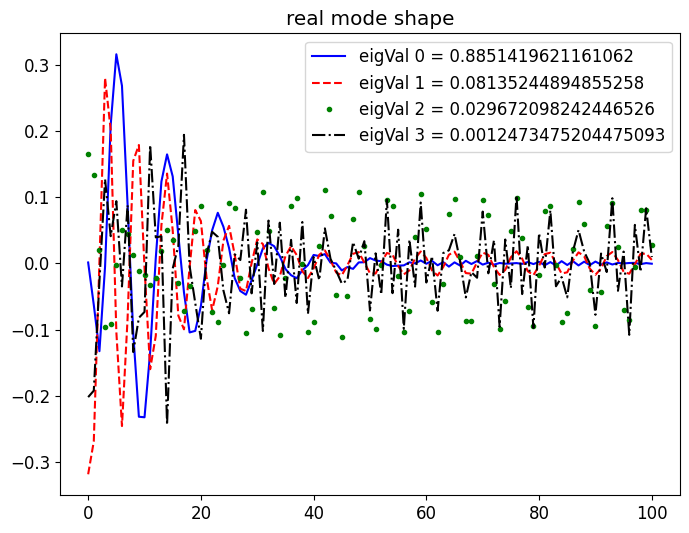

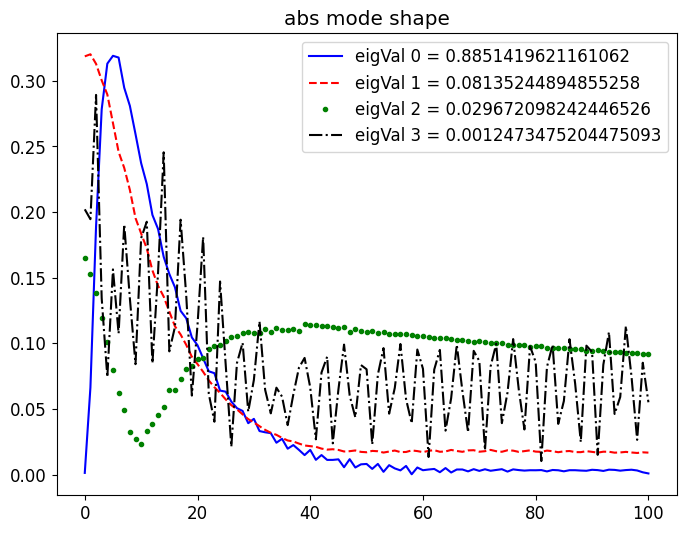

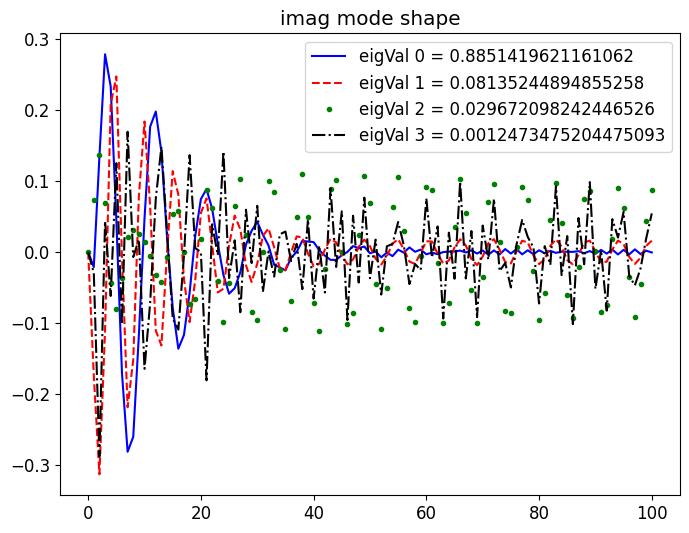

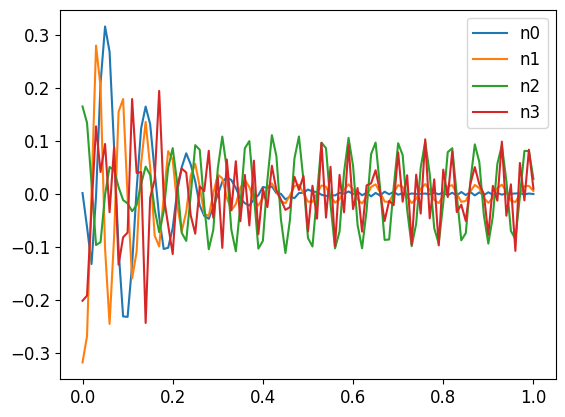

In [222]:
nMax = 4
eigenModes = highestEigFuncs(pickuptime, g_corr_matrix, nMax=nMax, plotAbs=True, plotImag=True)

fig, axes = plt.subplots()
tList2 =pickuptime
for i in range(nMax):
    axes.plot(tList2, np.real(eigenModes[i](tList2)), label='n'+str(i))
axes.legend()

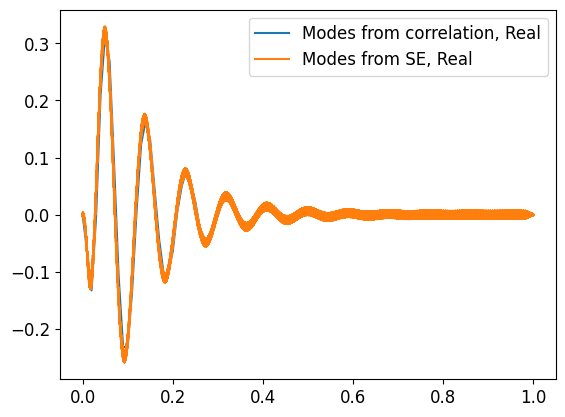

In [233]:
norm_factor=np.sqrt(len(t)/len(tList2))*1/np.sqrt(np.sum(np.abs(tmf_time)**2))
plt.plot(tList2, np.real(eigenModes[0](tList2)), label='Modes from correlation, Real')
plt.plot(t, np.imag(tmf_time)*norm_factor, label='Modes from SE, Real')
plt.legend()

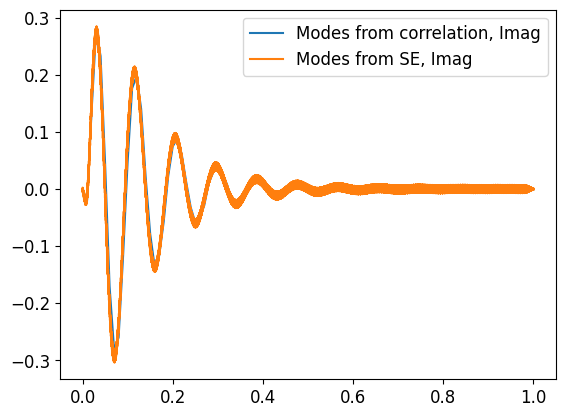

In [234]:
plt.plot(tList2, np.imag(eigenModes[0](tList2)), label='Modes from correlation, Imag')
plt.plot(t, -norm_factor*np.real(tmf_time), label='Modes from SE, Imag')
plt.legend()

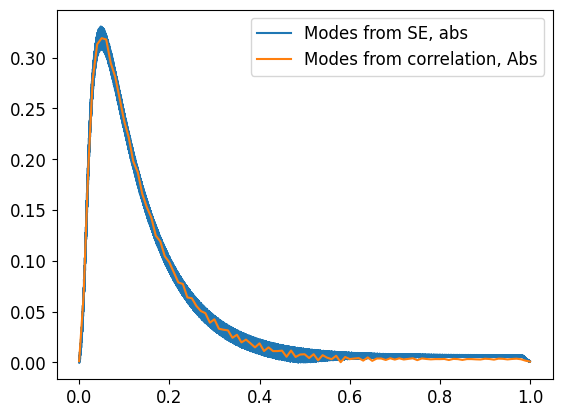

In [235]:
plt.plot(t, norm_factor*np.abs(tmf_time), label='Modes from SE, abs')
plt.plot(tList2, np.abs(eigenModes[0](tList2)), label='Modes from correlation, Abs')
plt.legend()

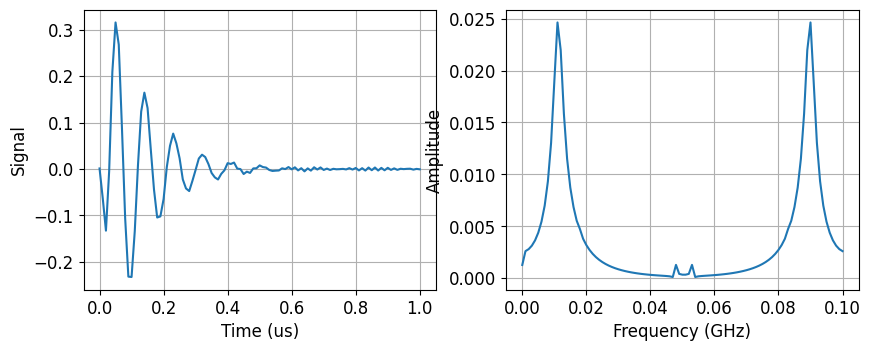

In [195]:
# 時間信号（周波数5の正弦波 + 周波数40の正弦波）の生成
freq = np.linspace(0, 1.0/(tList2[1]-tList2[0]), len(tList2))
f3=np.real(eigenModes[0](tList2))
# 高速フーリエ変換（周波数信号に変換）
F3 = np.fft.fft(f3)

# 正規化 + 交流成分2倍
F3 = F3/(len(tList2)-1/2)
F3[0] = F3[0]/2

# グラフ表示
fig = plt.figure(figsize=(10.0, 8.0))
plt.rcParams['font.family'] = ' '
plt.rcParams['font.size'] = 12

# 時間信号（元）
plt.subplot(221)
plt.plot(tList2, f3, label='f(n)')
plt.xlabel("Time (us)", fontsize=12)
plt.ylabel("Signal", fontsize=12)
plt.grid()
# leg = plt.legend(loc=1, fontsize=15)
# leg.get_frame().set_alpha(1)

# 周波数信号(元)
plt.subplot(222)
plt.plot(freq/1000, np.abs(F3), label='|F(k)|')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid()
# leg = plt.legend(loc=1, fontsize=15)
# leg.get_frame().set_alpha(1)

Max Freq at point=11
Max Freq at freq=11.0MHz


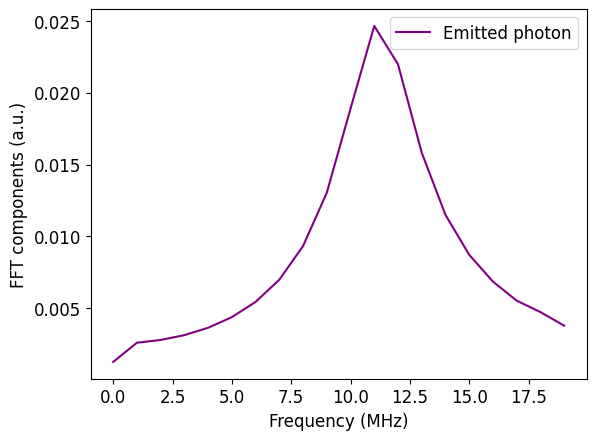

In [197]:
s1=0
s2=20
plt.plot(freq[s1:s2], np.abs(F3)[s1:s2],'purple', label='Emitted photon')
plt.xlabel('Frequency (MHz)')
plt.ylabel('FFT components (a.u.)')
plt.legend()
print("Max Freq at point="+str(list(np.abs(F3)[s1:s2]).index(max(np.abs(F3)[s1:s2]))))
print("Max Freq at freq="+str(freq[list(np.abs(F3)[s1:s2]).index(max(np.abs(F3)[s1:s2]))])+"MHz")

In [245]:
## scan fideilty of the qubit state with different initial?
phase_list=np.linspace(0,2,21)*np.pi

In [246]:
phase_list

array([0.        , 0.31415927, 0.62831853, 0.9424778 , 1.25663706,
       1.57079633, 1.88495559, 2.19911486, 2.51327412, 2.82743339,
       3.14159265, 3.45575192, 3.76991118, 4.08407045, 4.39822972,
       4.71238898, 5.02654825, 5.34070751, 5.65486678, 5.96902604,
       6.28318531])

In [248]:
rho_list=[]
ph_list=[]
co_list=[]
for oo in range(len(phase_list)):
    print("Calculating "+str(oo)+" polar angle")
    testinitialstate_tmp=tensor((np.cos(phase_list[oo]/2)*initialstateg0+\
               np.sin(phase_list[oo]/2)*initialstatef0),basis(Nout_res)).unit()
    output_decay_f0g1_with_outmode_tmf_se_tmp = \
    mesolve(H_f0g1_with_outmode_tmf_se,testinitialstate_tmp, t_new, c_ops=c_ops_new_tmf_se,progress_bar=True)
    tmp_ph_list=[output_decay_f0g1_with_outmode_tmf_se_tmp.states[tidx].ptrace(2)[1,1]\
               for tidx in range(len(output_decay_f0g1_with_outmode_tmf_se_tmp.states))]
    tmp_co_list=[output_decay_f0g1_with_outmode_tmf_se_tmp.states[tidx].ptrace(2)[0,1]\
               for tidx in range(len(output_decay_f0g1_with_outmode_tmf_se_tmp.states))]
    finalrho=output_decay_f0g1_with_outmode_tmf_se_tmp.states[-1]
    rho_list.append(finalrho)
    ph_list.append(tmp_ph_list)
    co_list.append(tmp_co_list)
    qsave(tmp_ph_list,'Fock1_ocup_number_at_'+str(oo)+'_phase')
    qsave(tmp_co_list,'Coherence_ocup_number_at_'+str(oo)+'_phase')
#results, final move to the data folder
qsave(rho_list,'Final_rho_lists')

Calculating 0 polar angle
10.0%. Run time:  44.13s. Est. time left: 00:00:06:37
20.0%. Run time:  95.53s. Est. time left: 00:00:06:22
30.0%. Run time: 153.12s. Est. time left: 00:00:05:57
40.0%. Run time: 216.75s. Est. time left: 00:00:05:25
50.0%. Run time: 286.88s. Est. time left: 00:00:04:46
60.0%. Run time: 363.34s. Est. time left: 00:00:04:02
70.0%. Run time: 446.30s. Est. time left: 00:00:03:11
80.0%. Run time: 535.68s. Est. time left: 00:00:02:13
90.0%. Run time: 631.44s. Est. time left: 00:00:01:10
Total run time: 732.39s
Calculating 1 polar angle
10.0%. Run time:  34.57s. Est. time left: 00:00:05:11
20.0%. Run time:  71.02s. Est. time left: 00:00:04:44
30.0%. Run time: 111.05s. Est. time left: 00:00:04:19
40.0%. Run time: 156.79s. Est. time left: 00:00:03:55
50.0%. Run time: 207.66s. Est. time left: 00:00:03:27
60.0%. Run time: 262.37s. Est. time left: 00:00:02:54
70.0%. Run time: 321.33s. Est. time left: 00:00:02:17
80.0%. Run time: 384.73s. Est. time left: 00:00:01:36
90.0%.

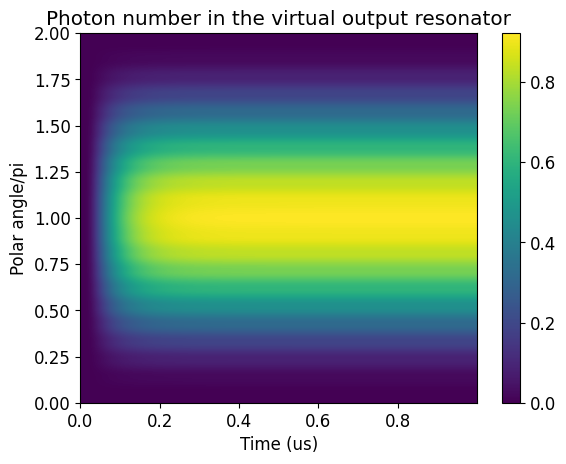

In [249]:
plt.imshow(np.real(ph_list),aspect='auto',extent = [0, t_new[-1],phase_list[0]/np.pi , phase_list[-1]/np.pi])
plt.xlabel("Time (us)")
plt.ylabel("Polar angle/pi")
plt.title("Photon number in the virtual output resonator")
plt.colorbar()


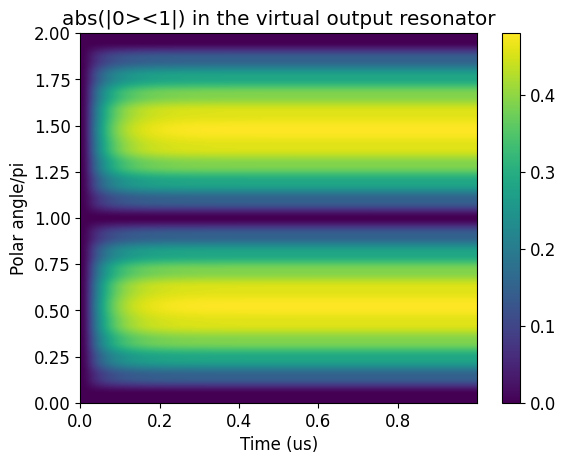

In [250]:
plt.imshow(np.abs(co_list),aspect='auto',extent = [0, t_new[-1],phase_list[0]/np.pi , phase_list[-1]/np.pi])
plt.xlabel("Time (us)")
plt.ylabel("Polar angle/pi")
plt.title("abs(|0><1|) in the virtual output resonator")
plt.colorbar()


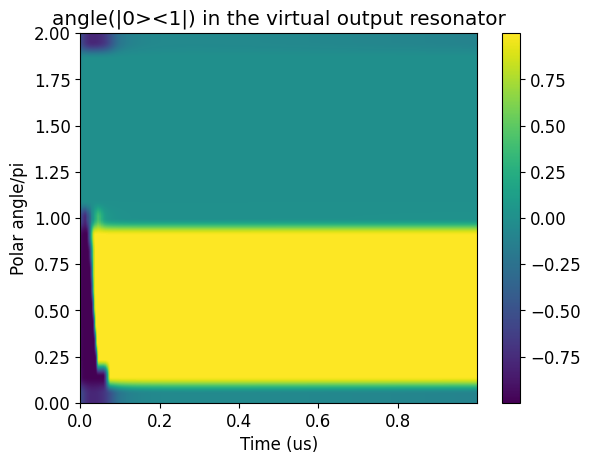

In [251]:
plt.imshow(np.angle(co_list)/np.pi,aspect='auto',extent = [0, t_new[-1],phase_list[0]/np.pi , phase_list[-1]/np.pi])
plt.xlabel("Time (us)")
plt.ylabel("Polar angle/pi")
plt.title("angle(|0><1|) in the virtual output resonator")
plt.colorbar()


In [252]:
def sin2_half_x(x, A, B):
    """Model function for y = A * sin^2(x/2) + B"""
    return A * np.sin(x / 2)**2 + B

def sin_x(x, A, B):
    """Model function for y = A * sin(x) + B"""
    return A * np.sin(x) + B
    
def fit_photon(xdata, ydata):
    """Fit data to y = sin^2(x/2)"""
    # Initial guess for parameters A and B
    initial_guess = [1, 0]
    params, params_covariance = curve_fit(sin2_half_x, xdata, ydata, p0=initial_guess)
    return params

def fit_coherence(xdata, ydata):
    """Fit data to y = sin(x)"""
    # Initial guess for parameters A and B
    initial_guess = [1, 0]
    params, params_covariance = curve_fit(sin_x, xdata, ydata, p0=initial_guess)
    return params


In [253]:
params1 = fit_photon(phase_list, np.real(ph_list)[:,-1])
params2 = fit_coherence(phase_list, np.real(co_list)[:,-1])
print("Fitted parameters for Photon fitting:", params1)
print("Fitted parameters for Coherence fitting:", params2)


Fitted parameters for Photon fitting: [ 9.22094720e-01 -6.10722335e-05]
Fitted parameters for Coherence fitting: [4.79840029e-01 6.56055000e-05]


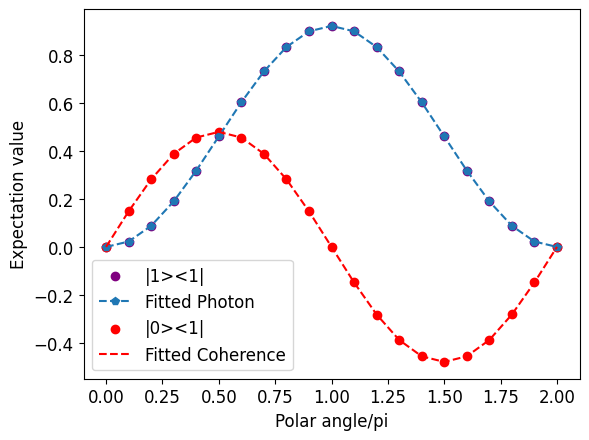

In [254]:
plt.scatter(phase_list/np.pi,np.real(ph_list)[:,-1],c='purple',label="|1><1|")
plt.plot(phase_list/np.pi, sin2_half_x(phase_list, *params1), 'p--', label='Fitted Photon')
plt.scatter(phase_list/np.pi,np.real(co_list)[:,-1],c='red',label="|0><1|")
plt.plot(phase_list/np.pi, sin_x(phase_list, *params2), 'r--',label='Fitted Coherence')
plt.ylabel("Expectation value")
plt.xlabel("Polar angle/pi")
plt.legend()

In [255]:
purity_total_state=[rho_list[ccc].purity() for ccc in range(len(phase_list))]
purity_res_state=[rho_list[ccc].ptrace(2).purity() for ccc in range(len(phase_list))]

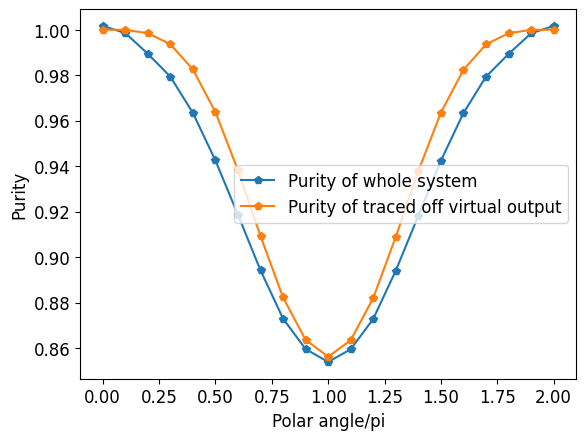

In [256]:
plt.plot(phase_list/np.pi, purity_total_state, 'p-', label='Purity of whole system')
plt.plot(phase_list/np.pi, purity_res_state, 'p-',label='Purity of traced off virtual output')
plt.ylabel("Purity")
plt.xlabel("Polar angle/pi")
plt.legend()